<a href="https://colab.research.google.com/github/anamijaz2021-qmul/Hematological-parameters-with-exfuzzy/blob/main/Copy_of_EDA_applied_on_cleaned_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
## Phase 1 — Environment, Data Loading & Cleaning

In [ ]:
import subprocess, sys
def pip_install(*pkgs):
    subprocess.check_call([sys.executable,'-m','pip','install','-q',*pkgs])

pip_install('ydata-profiling','missingno','umap-learn','plotly',
            'scikit-learn','scipy','openpyxl','ex-fuzzy','scikit-fuzzy')

import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import missingno as msno
from pandas.plotting import parallel_coordinates

from scipy.stats import (pearsonr, spearmanr, chi2_contingency,
                          mannwhitneyu, shapiro, zscore, pointbiserialr)
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors, KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.feature_selection import RFECV
from sklearn.model_selection import (StratifiedKFold, cross_val_score,
                                      train_test_split)
from sklearn.metrics import (silhouette_score, confusion_matrix,
                               classification_report, ConfusionMatrixDisplay)
from scipy.cluster.hierarchy import dendrogram, linkage
import skfuzzy as fuzz

try:
    import umap.umap_ as umap_module; UMAP_OK = True
except: UMAP_OK = False

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style='whitegrid', context='notebook', font_scale=1.1)

LABEL_MAP = {
    'Gender':      {0:'Female', 1:'Male'},
    'Diabetes':    {0:'No', 1:'Yes'},
    'Hypertension':{0:'No', 1:'Yes'},
    'Family H':    {0:'No', 1:'Yes'},
    'Smoking':     {0:'Non-smoker', 1:'Smoker'},
}
CATEGORICAL = ['Gender','Diabetes','Hypertension','Family H','Smoking']
print('✅  All imports successful')

✅  All imports successful


### Section 2 — Data Loading

In [ ]:
# ── Load pre-cleaned Excel file directly ─────────────────────────────────────
from google.colab import files
import pandas as pd
import numpy as np

uploaded = files.upload()  # Upload your cleaned .xlsx here
FILE = list(uploaded.keys())[0]

df_clean = pd.read_excel(FILE)
df_clean = df_clean.loc[:, ~df_clean.columns.str.contains('^Unnamed')]

print(f'✅ Cleaned file loaded: {FILE}')
print(f'Shape: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns')
df_clean.head(3)

Saving Hematological_parameters_CLEANED_v2.xlsx to Hematological_parameters_CLEANED_v2 (3).xlsx
✅ Cleaned file loaded: Hematological_parameters_CLEANED_v2 (3).xlsx
Shape: 306 rows × 31 columns


,IHD,Gender,Age,Diabetes,Hypertension,Family H,WBC,RBC,HGB,HCT,MCV,MCH,MCHC,PLT,%Neut,%LYMP,%MONO,Sodium,Potassium,Chloride,AST,Urea,Creatinine,Total Bilirubin,Alkaline Phosphatase,ALT,TG,TC,VLDL,LDL,HDL
0,1,0,75.000,1,1,0,8.400,4.170,11.300,34.000,81.500,27.200,33.400,191.000,48.000,54.000,3.000,136.000,4.400,98.000,22.500,35.000,0.900,0.600,107.198,25.000,330,249,21.000,220,25
1,2,0,76.000,0,1,1,11.700,4.200,12.400,36.000,86.000,29.000,34.000,326.000,56.000,32.000,3.720,136.000,4.400,98.000,22.500,35.000,0.900,0.600,107.198,25.000,252,216,50.000,122,87
2,3,0,72.000,0,0,0,10.300,4.130,11.900,29.700,71.700,25.000,34.800,249.000,60.000,23.200,3.720,136.000,4.400,98.000,22.500,35.000,0.900,0.600,107.198,25.000,252,216,50.000,122,87


#Train/Test split

In [ ]:
# ── Train/Test split ──────────────────────────────────────────────────────────
TRAIN_FRAC = 0.70
indices = np.arange(len(df_clean))  # ← change df to df_clean
train_idx, test_idx = train_test_split(
    indices, train_size=TRAIN_FRAC, random_state=42, shuffle=True
)
print(f'Train/Test split: {len(train_idx)} train / {len(test_idx)} test patients')

Train/Test split: 214 train / 92 test patients


---
## Phase 2 — Descriptive & Inferential Analysis


### Section 5 — Statistical Summary & Normality Testing

In [ ]:
# ── Column definitions ────────────────────────────────────────────────────────
print(df_clean.columns.tolist())  # run this first to see all column names

['IHD', 'Gender', 'Age', 'Diabetes', 'Hypertension', 'Family H', 'WBC', 'RBC', 'HGB', 'HCT', 'MCV', 'MCH', 'MCHC', 'PLT', '%Neut', '%LYMP', '%MONO', 'Sodium', 'Potassium', 'Chloride', 'AST', 'Urea', 'Creatinine', 'Total Bilirubin', 'Alkaline Phosphatase', 'ALT', 'TG', 'TC', 'VLDL', 'LDL', 'HDL']


In [ ]:
# ── Column definitions ────────────────────────────────────────────────────────
ID_COLS  = ['IHD']   # target/ID column

CAT_COLS = ['Gender', 'Diabetes', 'Hypertension', 'Family H']  # categorical

NUM_COLS = [c for c in df_clean.columns
            if c not in ID_COLS + CAT_COLS]

print(f'NUM_COLS ({len(NUM_COLS)}): {NUM_COLS}')
print(f'CAT_COLS ({len(CAT_COLS)}): {CAT_COLS}')

NUM_COLS (26): ['Age', 'WBC', 'RBC', 'HGB', 'HCT', 'MCV', 'MCH', 'MCHC', 'PLT', '%Neut', '%LYMP', '%MONO', 'Sodium', 'Potassium', 'Chloride', 'AST', 'Urea', 'Creatinine', 'Total Bilirubin', 'Alkaline Phosphatase', 'ALT', 'TG', 'TC', 'VLDL', 'LDL', 'HDL']
CAT_COLS (4): ['Gender', 'Diabetes', 'Hypertension', 'Family H']


In [ ]:
# ── Enhanced statistical summary ─────────────────────────────────────────────
summary = df_clean[NUM_COLS].describe().T
summary['skewness'] = df_clean[NUM_COLS].skew()
summary['kurtosis'] = df_clean[NUM_COLS].kurtosis()
summary['cv_%']     = (df_clean[NUM_COLS].std()/df_clean[NUM_COLS].mean()*100).round(1)
# imputation_log_df not available (file is pre-cleaned), so mark all as pre-cleaned
summary['imputation_method'] = 'pre-cleaned'

summary.round(3).style.background_gradient(subset=['skewness'], cmap='coolwarm')

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis,cv_%,imputation_method
Age,306.000000,58.382000,11.224000,23.000000,51.000000,58.365000,66.750000,100.000000,-0.039000,0.288000,19.200000,pre-cleaned
WBC,306.000000,9.928000,2.726000,3.500000,8.025000,10.101000,11.275000,24.300000,0.915000,2.755000,27.500000,pre-cleaned
RBC,306.000000,4.746000,0.765000,2.820000,4.300000,4.625000,5.130000,9.668000,1.545000,6.698000,16.100000,pre-cleaned
HGB,306.000000,12.356000,1.803000,7.100000,11.400000,12.446000,13.275000,18.800000,0.122000,0.819000,14.600000,pre-cleaned
HCT,306.000000,37.711000,6.395000,3.200000,34.350000,37.900000,39.875000,75.375000,0.794000,8.742000,17.000000,pre-cleaned
MCV,306.000000,78.403000,7.812000,42.050000,75.600000,79.900000,82.575000,95.800000,-1.457000,4.136000,10.000000,pre-cleaned
MCH,306.000000,26.220000,3.536000,9.550000,24.800000,26.500000,27.900000,43.375000,0.348000,6.186000,13.500000,pre-cleaned
MCHC,306.000000,33.116000,1.950000,26.400000,32.000000,33.000000,33.900000,44.375000,1.030000,5.763000,5.900000,pre-cleaned
PLT,306.000000,243.495000,91.069000,4.700000,201.000000,239.000000,277.750000,683.000000,0.947000,3.295000,37.400000,pre-cleaned
%Neut,306.000000,62.117000,10.499000,15.100000,56.200000,62.850000,66.500000,114.600000,0.546000,5.320000,16.900000,pre-cleaned


In [ ]:
# ── Normality testing (Shapiro-Wilk) ─────────────────────────────────────────
norm_results = {}
for col in NUM_COLS:
    s = df_clean[col].dropna()
    if len(s) >= 8:
        samp = s.sample(min(200,len(s)), random_state=42)
        stat, p = shapiro(samp)
        norm_results[col] = {'n':len(s), 'W':round(stat,4), 'p':round(p,5), 'normal': p>0.05}

norm_df = pd.DataFrame(norm_results).T.sort_values('p')
# norm_df['normal'] ends up as object dtype (mixed int/float/bool
# values transposed from a dict of dicts), so pandas .sum() on it performs
# logical OR rather than counting True values — silently returning a bare
# True/False instead of a number. Counting from the underlying dict avoids
# the dtype issue entirely.
n_normal = sum(1 for v in norm_results.values() if v['normal'])
print(f'Normally distributed (p>0.05): {n_normal}/{len(norm_df)} variables')
print('Non-parametric tests (Spearman, Mann-Whitney) are used throughout.')
norm_df.head(10)

Normally distributed (p>0.05): 1/26 variables
Non-parametric tests (Spearman, Mann-Whitney) are used throughout.


,n,W,p,normal
Sodium,306,0.816,0.000,False
VLDL,306,0.869,0.000,False
TC,306,0.926,0.000,False
TG,306,0.935,0.000,False
ALT,306,0.868,0.000,False
Alkaline Phosphatase,306,0.924,0.000,False
Total Bilirubin,306,0.724,0.000,False
Creatinine,306,0.728,0.000,False
Urea,306,0.787,0.000,False
AST,306,0.876,0.000,False


### Section 6 — Distribution Panels

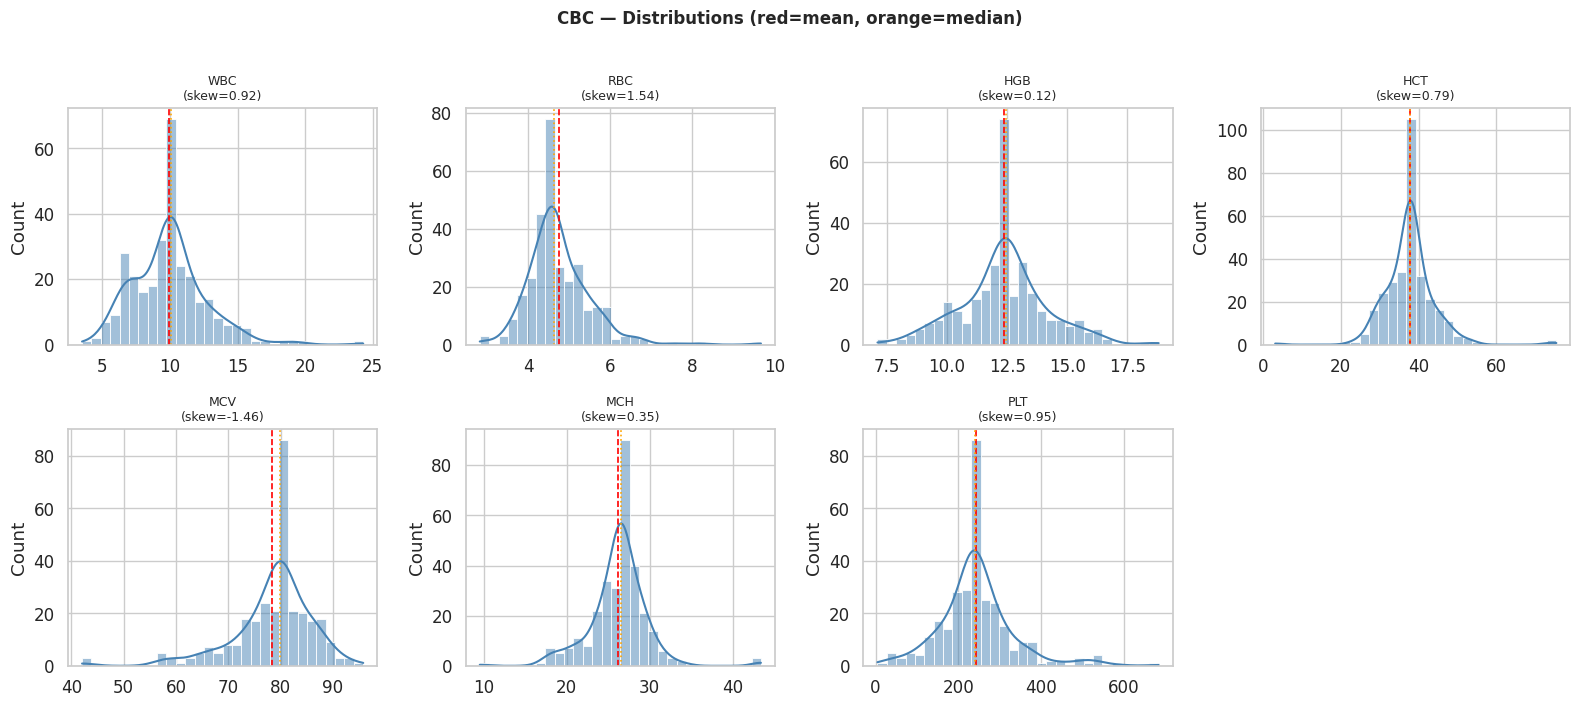

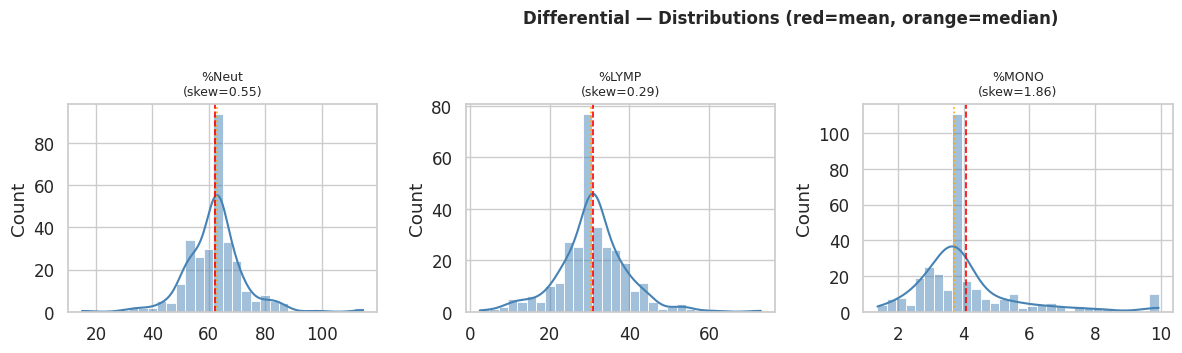

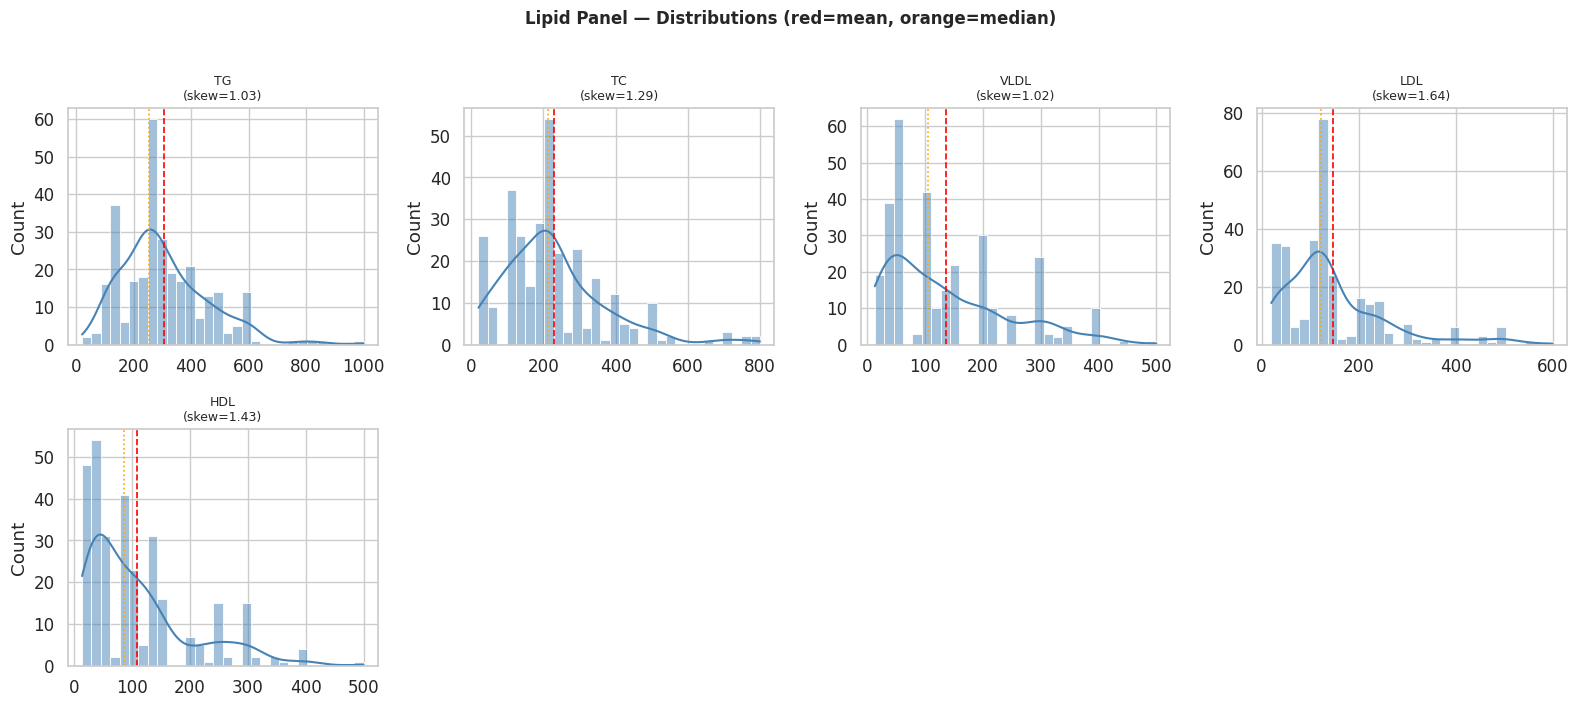

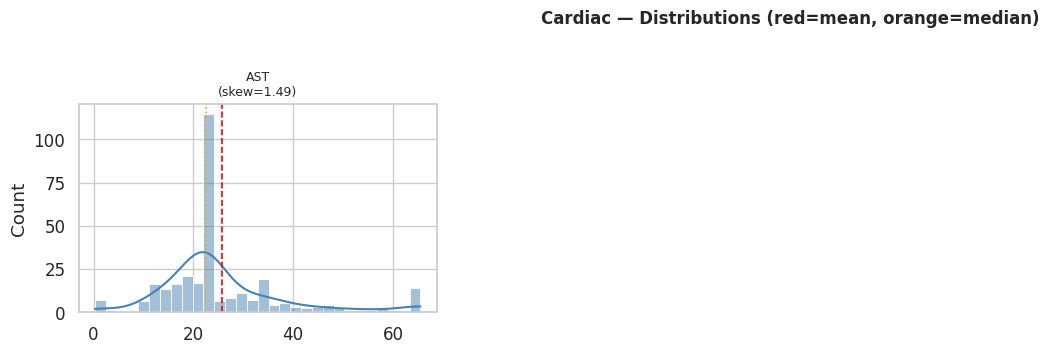

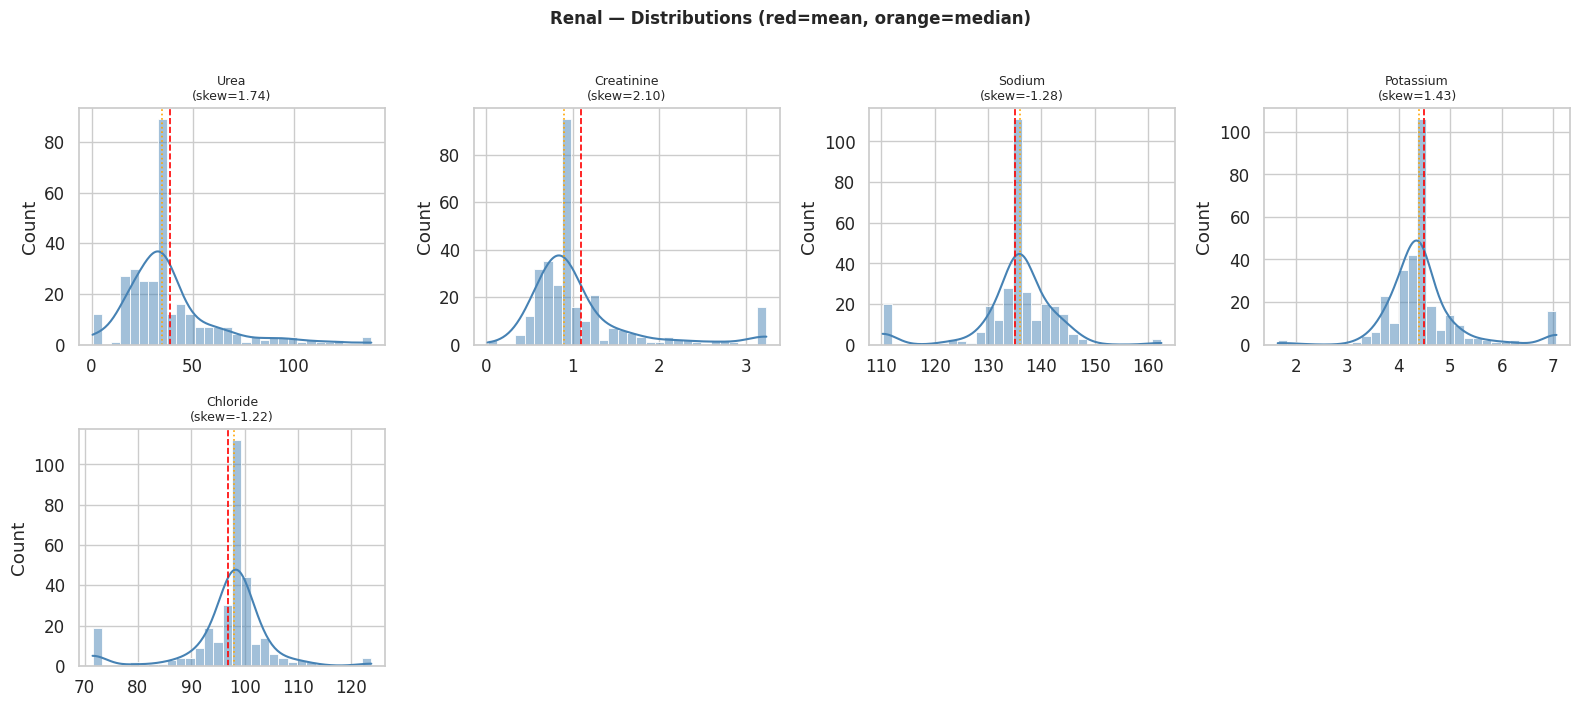

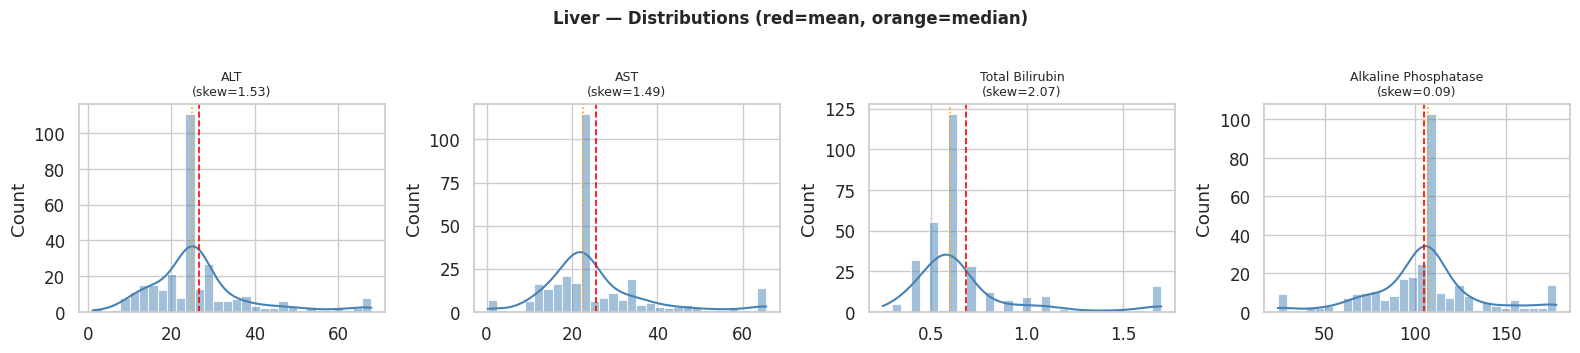

In [ ]:
# ── Clinical panel groups ────────────────────────────────────────────────────
CBC    = [c for c in ['WBC','RBC','HGB','HCT','MCV','MCH','PLT'] if c in df_clean.columns]
DIFF   = [c for c in ['%Neut','%LYMP','%MONO','%EOS'] if c in df_clean.columns]
LIPIDS = [c for c in ['TG','TC','VLDL','LDL','HDL'] if c in df_clean.columns]
CARDIAC= [c for c in ['CK','CK-MB','LDH','AST','Troponin-I'] if c in df_clean.columns]
RENAL  = [c for c in ['Urea','Creatinine','Sodium','Potassium','Chloride'] if c in df_clean.columns]
LIVER  = [c for c in ['ALT','AST','Total Bilirubin','Alkaline Phosphatase'] if c in df_clean.columns]
GLUCOSE= [c for c in ['GLUCOSE(random)','Glucose (Fasting)','Glucose (Random)'] if c in df_clean.columns]

def plot_distributions(cols, group_name, n_cols=4):
    valid = [c for c in cols if df_clean[c].notna().sum()>5]
    if not valid: return
    n_rows = (len(valid)-1)//n_cols+1
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*3.5))
    axes = np.array(axes).flatten()
    for i, col in enumerate(valid):
        data = df_clean[col].dropna()
        sns.histplot(data, kde=True, ax=axes[i], color='steelblue', bins=30)
        axes[i].axvline(data.mean(), color='red', linestyle='--', linewidth=1.2)
        axes[i].axvline(data.median(), color='orange', linestyle=':', linewidth=1.2)
        axes[i].set_title(f'{col}\n(skew={data.skew():.2f})', fontsize=9)
        axes[i].set_xlabel('')
    for j in range(len(valid),len(axes)): axes[j].set_visible(False)
    fig.suptitle(f'{group_name} — Distributions (red=mean, orange=median)',
                 fontsize=12, fontweight='bold', y=1.01)
    plt.tight_layout(); plt.show()

for name, cols in [('CBC',CBC),('Differential',DIFF),('Lipid Panel',LIPIDS),
                    ('Cardiac',CARDIAC),('Renal',RENAL),('Liver',LIVER),('Glucose',GLUCOSE)]:
    plot_distributions(cols, name)


### Section 7 — Categorical Variables & Age Distribution

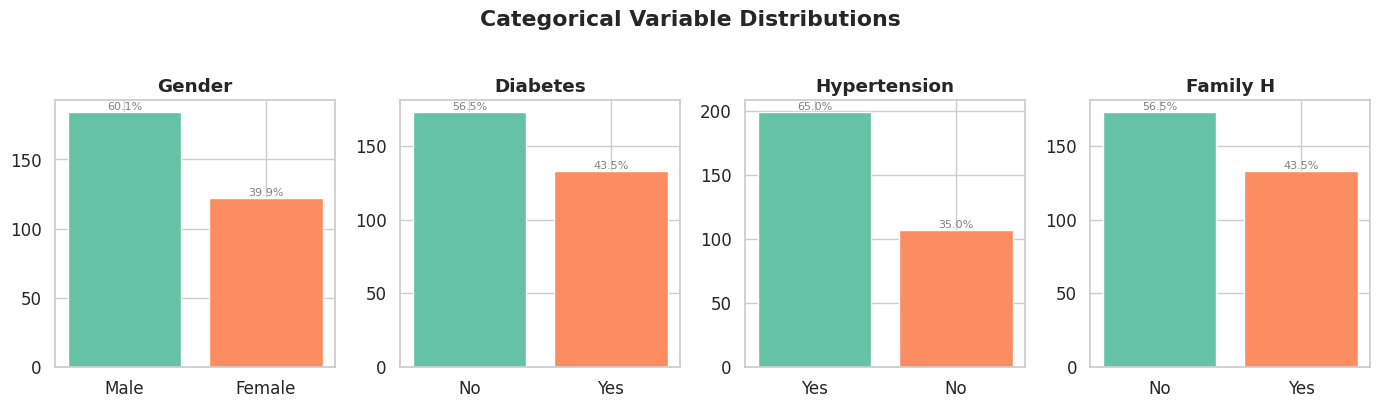

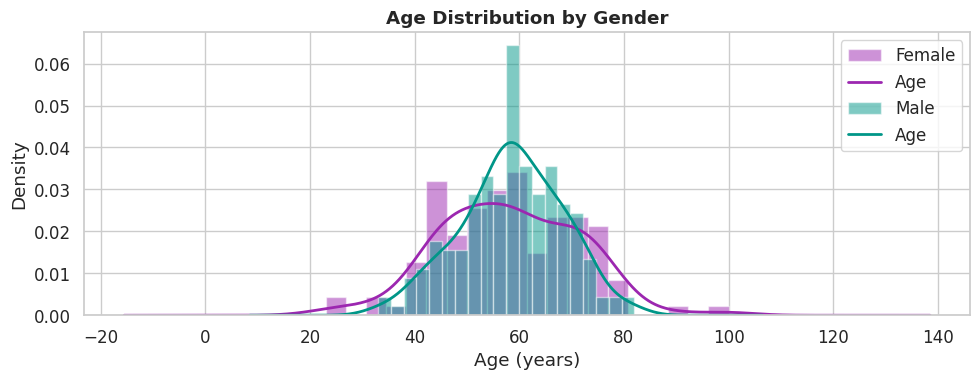

In [ ]:
# ── Categorical bar charts ───────────────────────────────────────────────────
cat_present = [c for c in CATEGORICAL if c in df_clean.columns]
fig, axes = plt.subplots(1, len(cat_present), figsize=(3.5*len(cat_present), 4))
if len(cat_present)==1: axes=[axes]
for ax, col in zip(axes, cat_present):
    vc = df_clean[col].map(LABEL_MAP.get(col,{})).fillna(df_clean[col]).value_counts(dropna=False)
    colors = sns.color_palette('Set2', len(vc))
    bars = ax.bar(vc.index.astype(str), vc.values, color=colors, edgecolor='white')
    ax.set_title(col, fontweight='bold')
    total = vc.sum()
    for bar, val in zip(bars, vc.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f'{val/total*100:.1f}%', ha='center', va='bottom', fontsize=8, color='grey')
fig.suptitle('Categorical Variable Distributions', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

if 'Age' in df_clean.columns and 'Gender' in df_clean.columns:
    df_clean['Gender_label'] = df_clean['Gender'].map({0:'Female',1:'Male'})
    fig, ax = plt.subplots(figsize=(10,4))
    for gender, color in [('Female','#9C27B0'),('Male','#009688')]:
        grp = df_clean[df_clean['Gender_label']==gender]['Age'].dropna()
        ax.hist(grp, bins=20, alpha=0.5, color=color, label=gender, density=True)
        grp.plot.kde(ax=ax, color=color, linewidth=2)
    ax.set_title('Age Distribution by Gender', fontweight='bold')
    ax.set_xlabel('Age (years)'); ax.legend()
    plt.tight_layout(); plt.show()


### Section 8 — Group Comparisons (Mann-Whitney U)

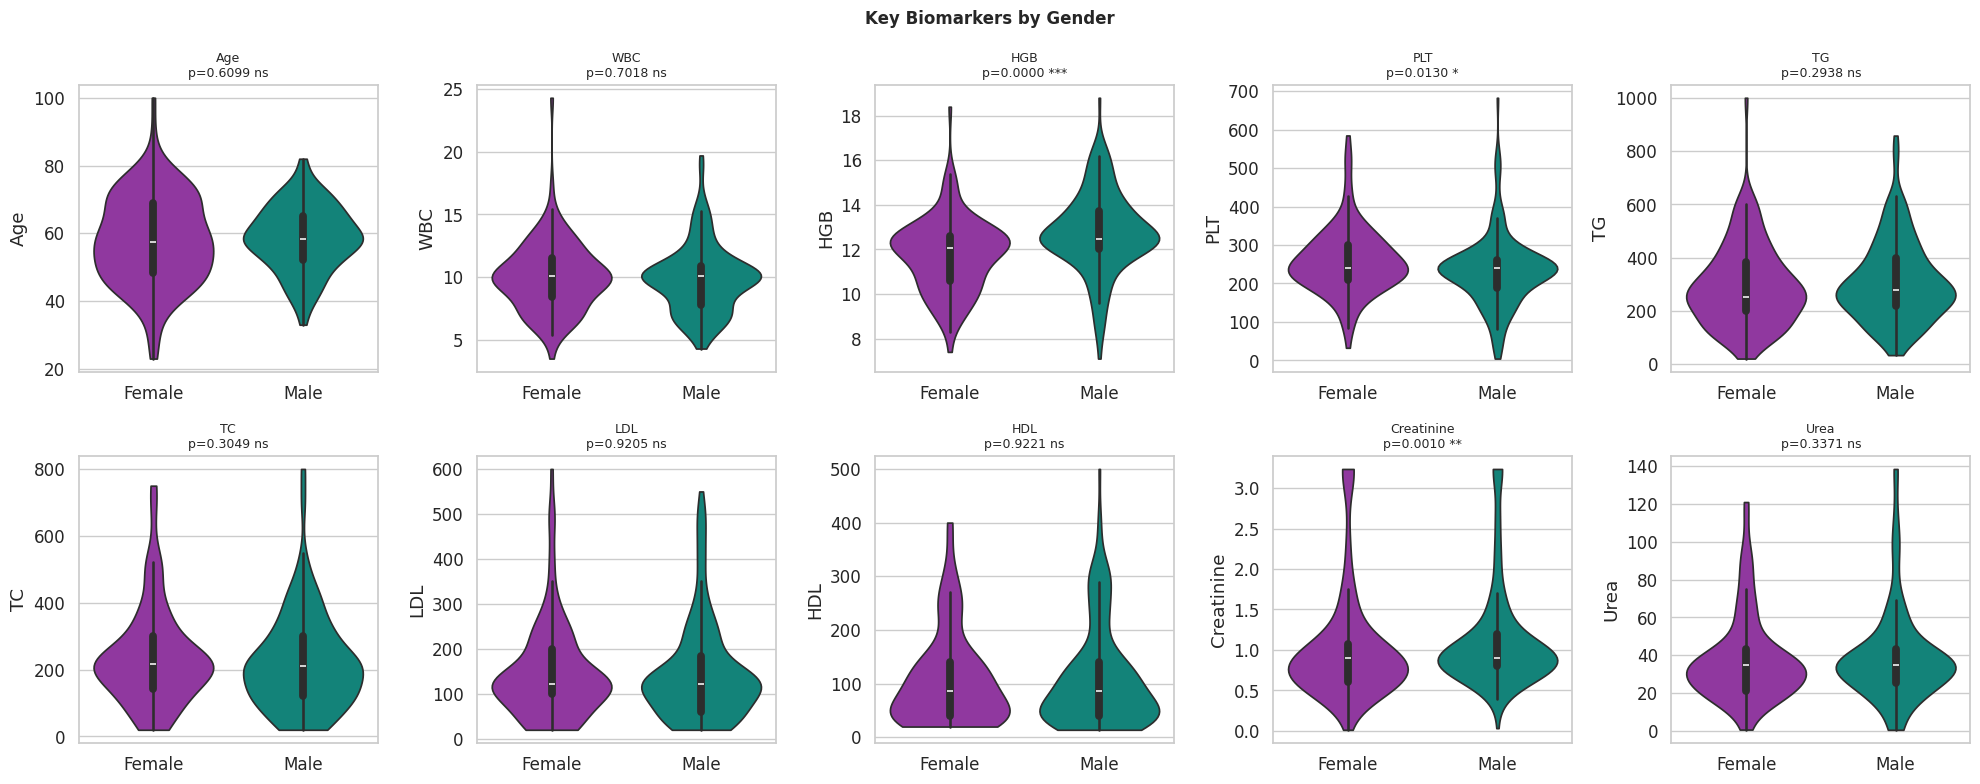

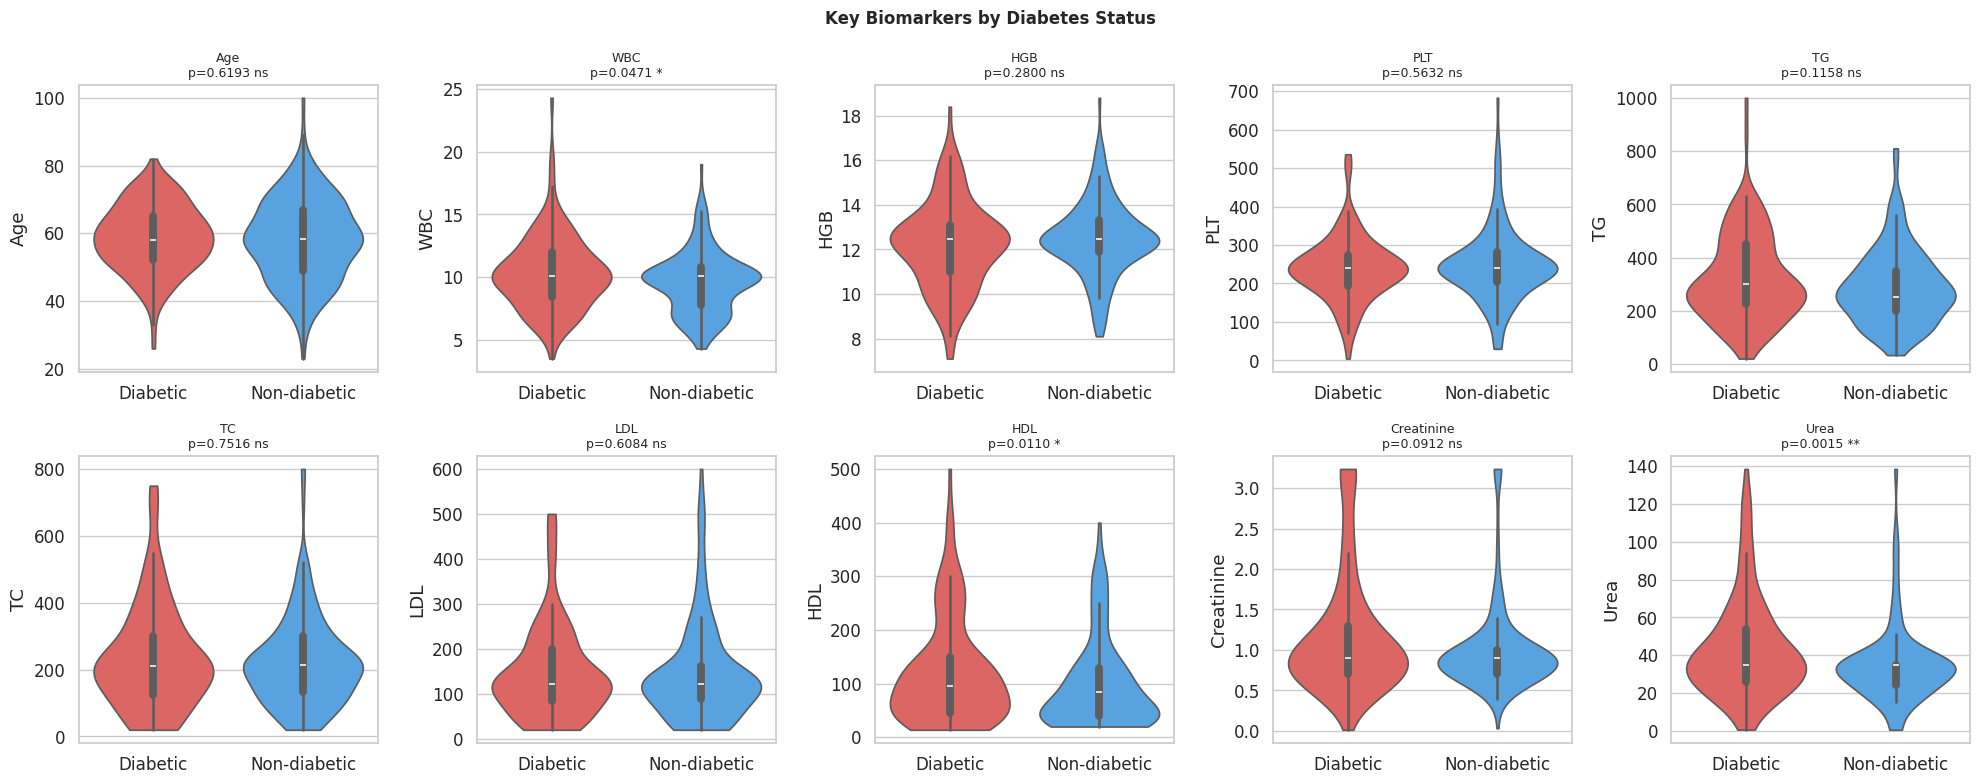

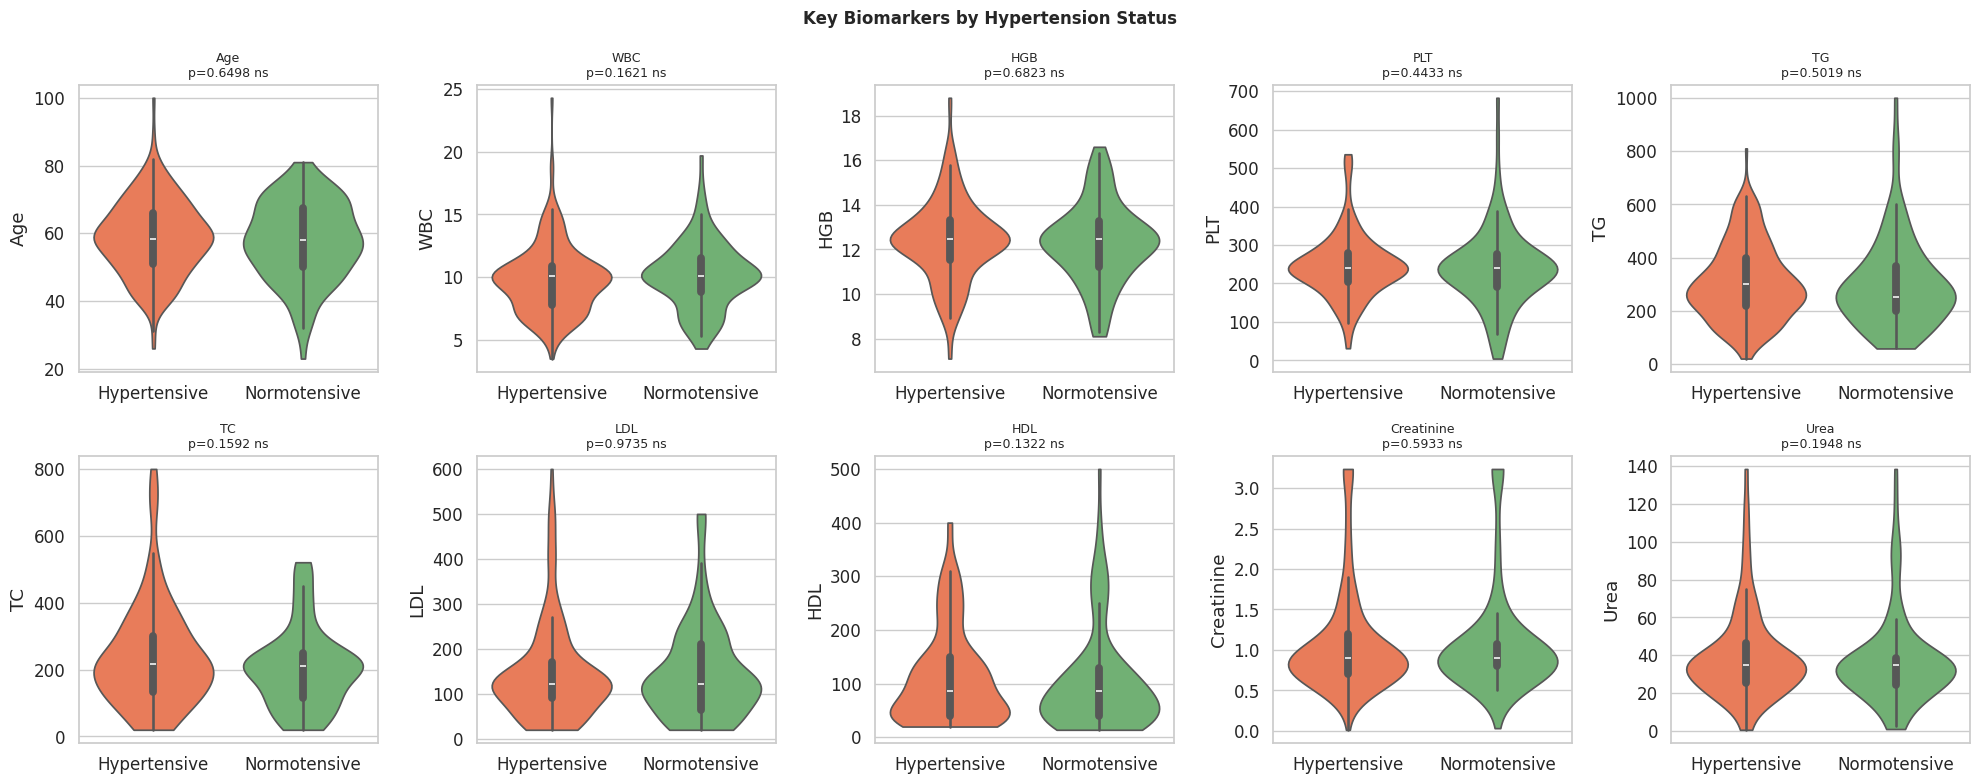

In [ ]:
# ── Biomarker comparison across categorical groups ────────────────────────────
KEY_BIO = [c for c in ['Age','WBC','HGB','PLT','TG','TC','LDL','HDL','Creatinine','Urea']
           if c in df_clean.columns]

def group_comparison_plot(group_col, group_map, title, palette, n_cols=5):
    if group_col not in df_clean.columns: return
    label_col = group_col+'_lbl'
    df_clean[label_col] = df_clean[group_col].map(group_map)
    n_rows = (len(KEY_BIO)-1)//n_cols+1
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*4))
    axes = np.array(axes).flatten()
    for i, col in enumerate(KEY_BIO):
        data = df_clean[[col, label_col]].dropna()
        sns.violinplot(data=data, x=label_col, y=col, ax=axes[i],
                       palette=palette, inner='box', cut=0)
        groups = [data[data[label_col]==g][col] for g in data[label_col].unique() if len(data[data[label_col]==g])>0]
        if len(groups)==2:
            _, p = mannwhitneyu(groups[0], groups[1], alternative='two-sided')
            sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
            axes[i].set_title(f'{col}\np={p:.4f} {sig}', fontsize=9)
        else:
            axes[i].set_title(col, fontsize=9)
        axes[i].set_xlabel('')
    for j in range(len(KEY_BIO),len(axes)): axes[j].set_visible(False)
    fig.suptitle(title, fontsize=12, fontweight='bold')
    plt.tight_layout(); plt.show()

group_comparison_plot('Gender',    {0:'Female',1:'Male'},
    'Key Biomarkers by Gender', {'Female':'#9C27B0','Male':'#009688'})
group_comparison_plot('Diabetes',  {0:'Non-diabetic',1:'Diabetic'},
    'Key Biomarkers by Diabetes Status', {'Non-diabetic':'#42A5F5','Diabetic':'#EF5350'})
group_comparison_plot('Hypertension',{0:'Normotensive',1:'Hypertensive'},
    'Key Biomarkers by Hypertension Status', {'Normotensive':'#66BB6A','Hypertensive':'#FF7043'})
group_comparison_plot('Smoking',   {0:'Non-smoker',1:'Smoker'},
    'Key Biomarkers by Smoking Status', {'Non-smoker':'#42A5F5','Smoker':'#795548'})

### Section 9 — Correlation Analysis

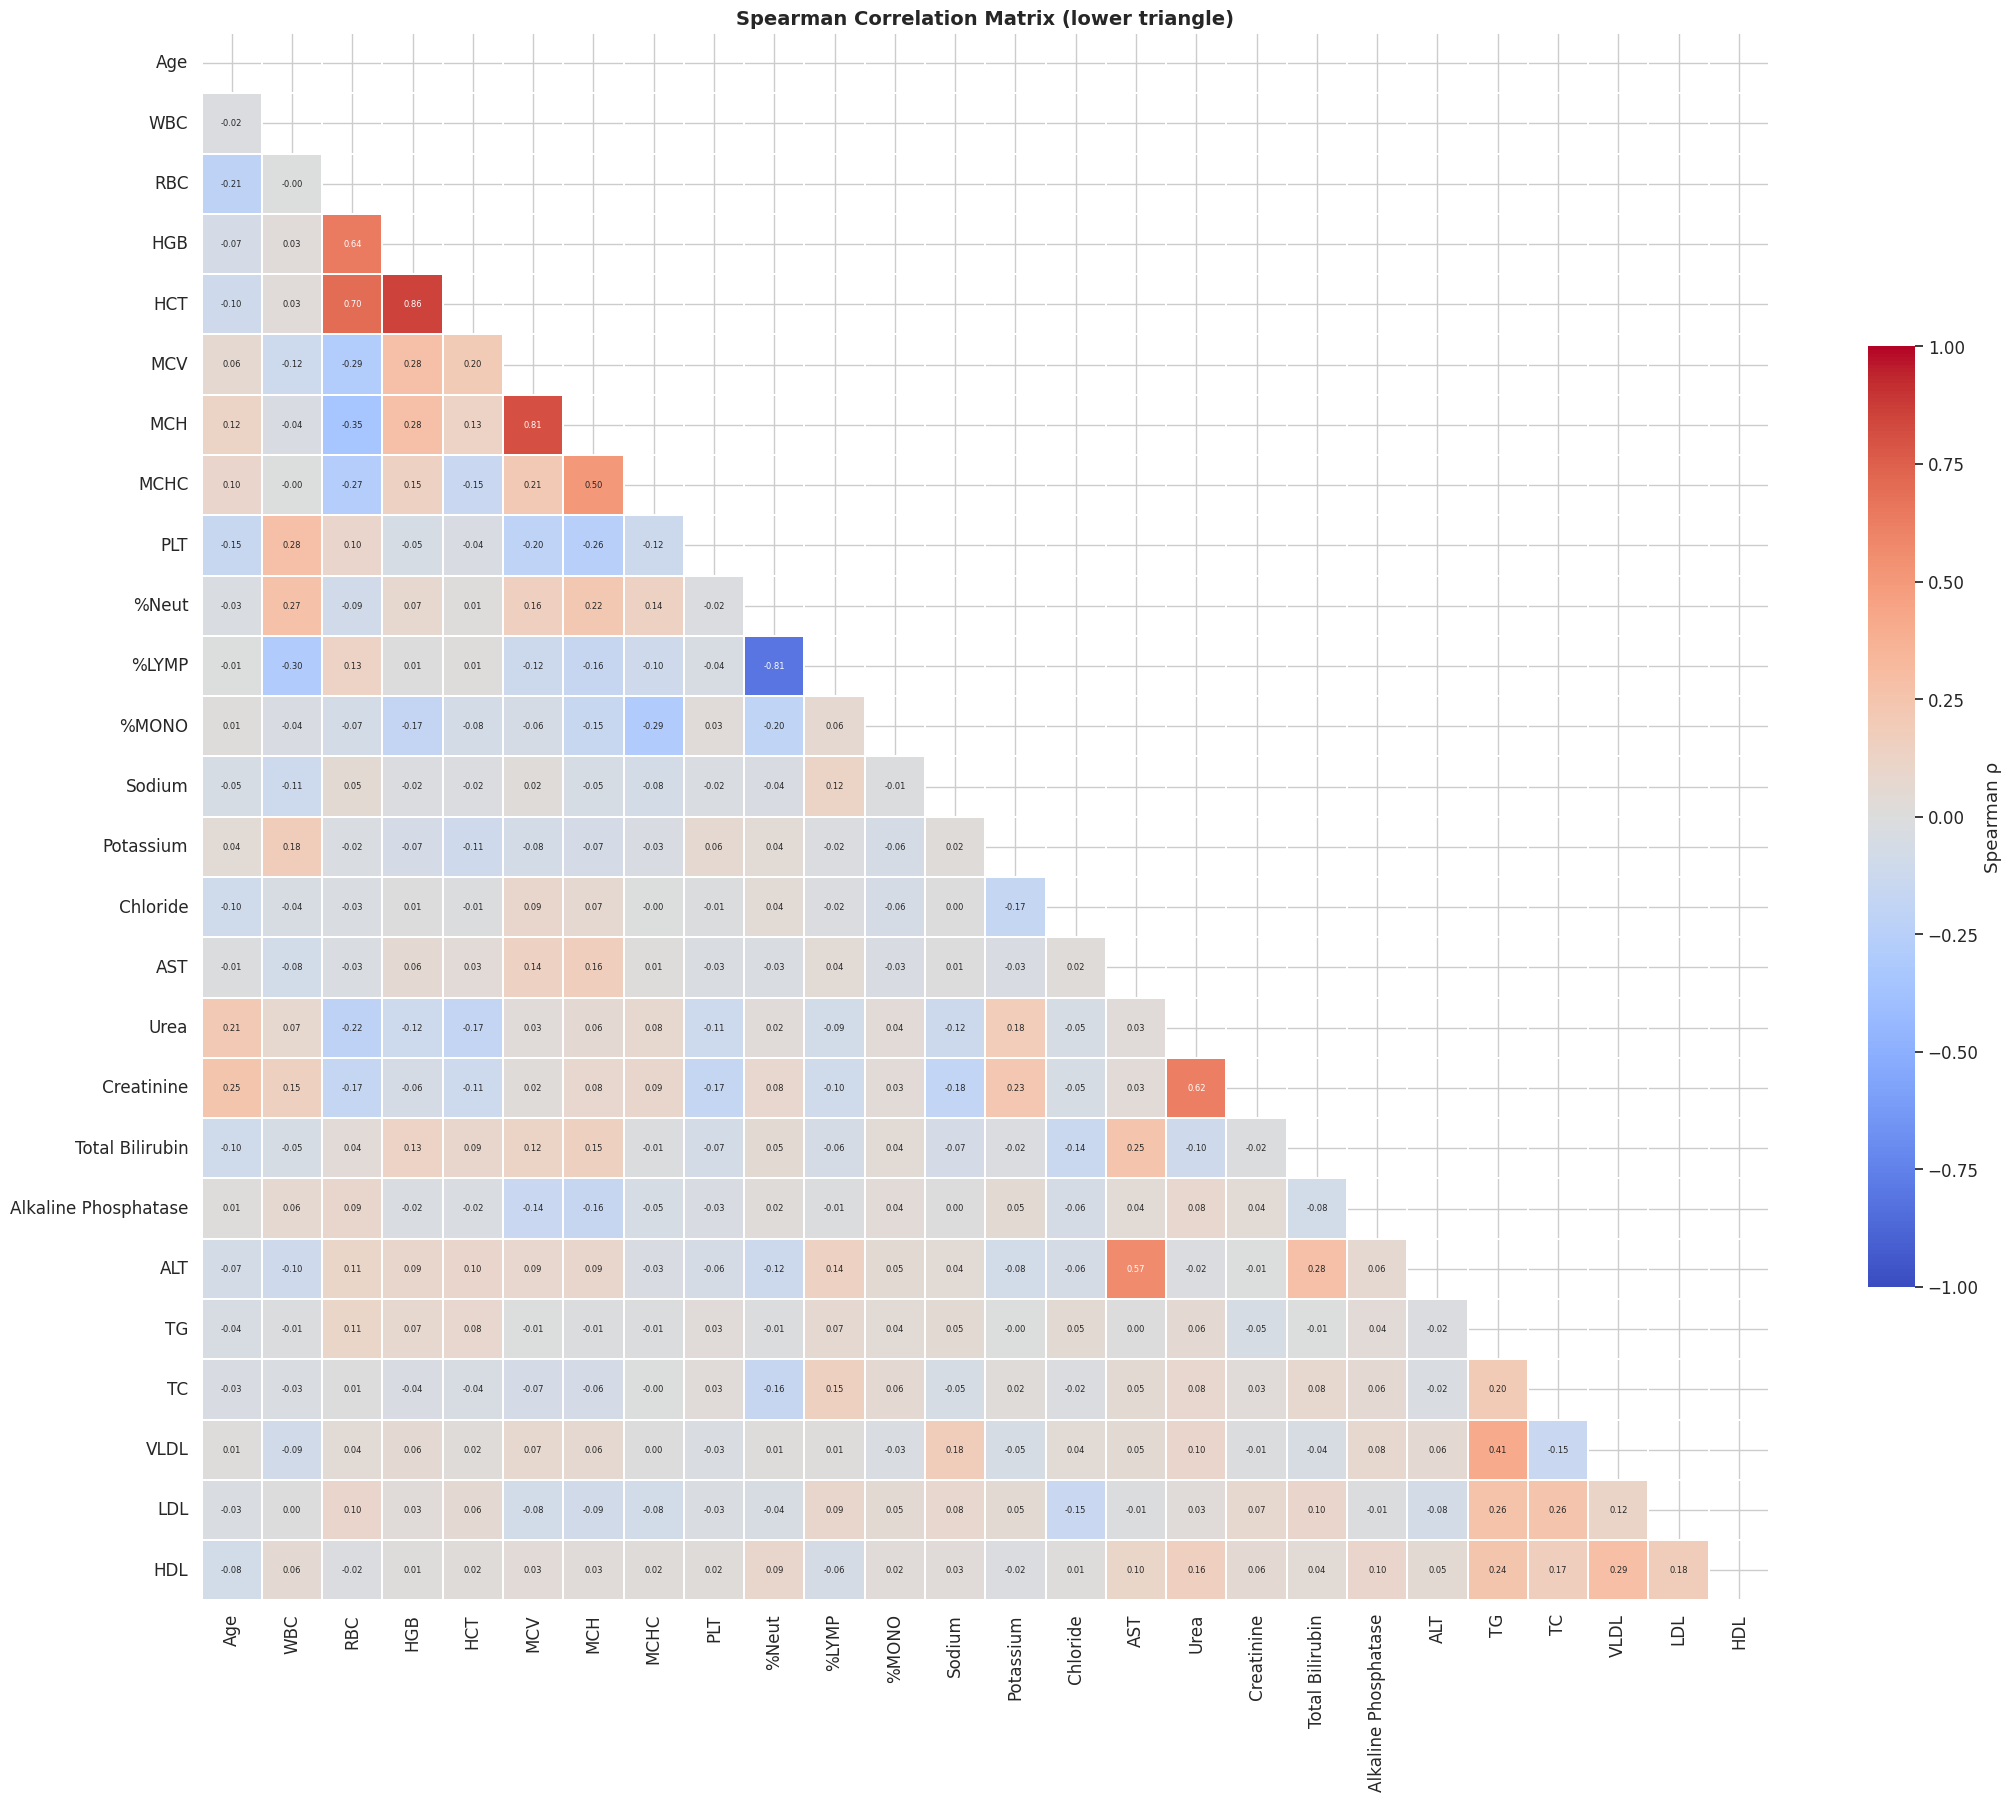

Top 20 correlated pairs:


,Var1,Var2,rho,abs_rho
9,HCT,HGB,0.855175,0.855175
20,MCH,MCV,0.809377,0.809377
54,%LYMP,%Neut,-0.805917,0.805917
8,HCT,RBC,0.697739,0.697739
5,HGB,RBC,0.635164,0.635164
152,Creatinine,Urea,0.620441,0.620441
205,ALT,AST,0.568405,0.568405
27,MCHC,MCH,0.503971,0.503971
274,VLDL,TG,0.408865,0.408865
17,MCH,RBC,-0.349758,0.349758


In [ ]:
# ── Spearman correlation heatmap ─────────────────────────────────────────────
spearman_corr = df_clean[NUM_COLS].corr(method='spearman')

fig, ax = plt.subplots(figsize=(22,18))
mask = np.triu(np.ones_like(spearman_corr, dtype=bool))
sns.heatmap(spearman_corr, mask=mask, annot=True, fmt='.2f', linewidths=0.3,
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            annot_kws={'size':6}, ax=ax, square=True,
            cbar_kws={'label':'Spearman ρ','shrink':0.6})
ax.set_title('Spearman Correlation Matrix (lower triangle)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

corr_pairs = (spearman_corr
    .where(np.tril(np.ones(spearman_corr.shape),k=-1).astype(bool))
    .stack().reset_index())
corr_pairs.columns = ['Var1','Var2','rho']
corr_pairs['abs_rho'] = corr_pairs['rho'].abs()
top_pairs = corr_pairs.sort_values('abs_rho', ascending=False).head(20)
print('Top 20 correlated pairs:')
top_pairs.style.bar(subset=['rho'], color=['#EF5350','#42A5F5'])

In [ ]:
# ── Chi-square between categorical variables ──────────────────────────────────
cat_valid = [c for c in CATEGORICAL if c in df_clean.columns]
chi2_results = []
for i in range(len(cat_valid)):
    for j in range(i+1,len(cat_valid)):
        a,b = cat_valid[i],cat_valid[j]
        ct = pd.crosstab(df_clean[a],df_clean[b])
        if ct.shape[0]>1 and ct.shape[1]>1:
            chi2,p,dof,_ = chi2_contingency(ct)
            n = ct.values.sum()
            v = np.sqrt(chi2/(n*(min(ct.shape)-1)))
            chi2_results.append({'Var_A':a,'Var_B':b,'chi2':round(chi2,2),
                                  'p':round(p,5),"Cramer's V":round(v,3),'sig':p<0.05})
chi2_df = pd.DataFrame(chi2_results).sort_values('p')
print('Chi-square associations:')
chi2_df.style.background_gradient(subset=["Cramer's V"],cmap='YlOrRd')

Chi-square associations:


,Var_A,Var_B,chi2,p,Cramer's V,sig
3,Diabetes,Hypertension,9.890000,0.001660,0.180000,True
1,Gender,Hypertension,6.190000,0.012860,0.142000,True
4,Diabetes,Family H,4.090000,0.043150,0.116000,True
0,Gender,Diabetes,2.320000,0.127310,0.087000,False
2,Gender,Family H,0.670000,0.413250,0.047000,False
5,Hypertension,Family H,0.240000,0.627500,0.028000,False


### Section 10 — PCA & t-SNE Dimensionality Reduction

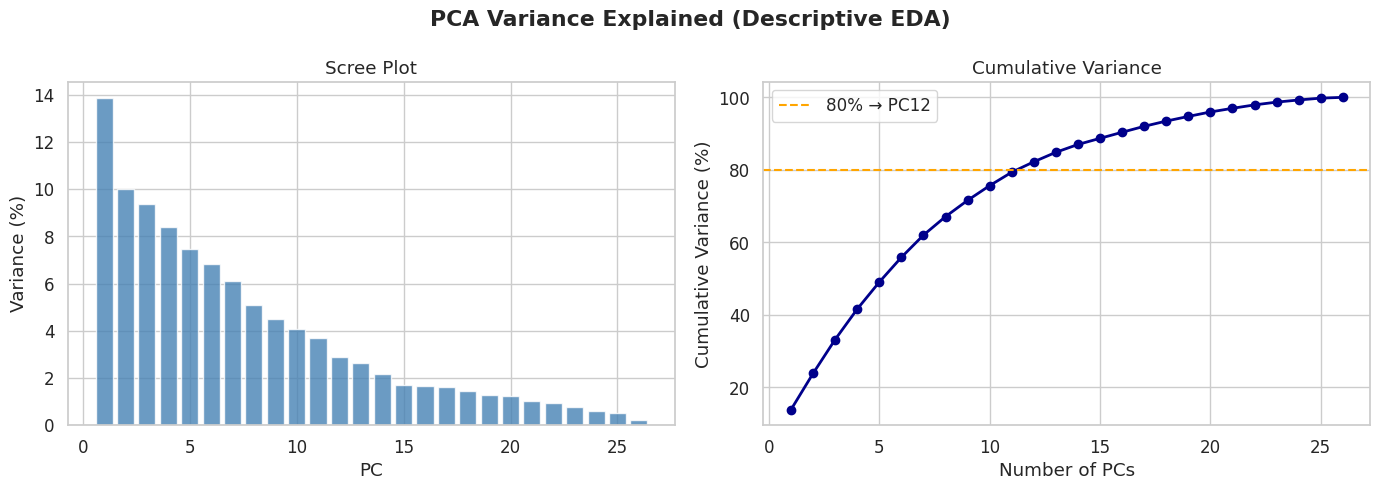

PCs needed for 80% variance: 12


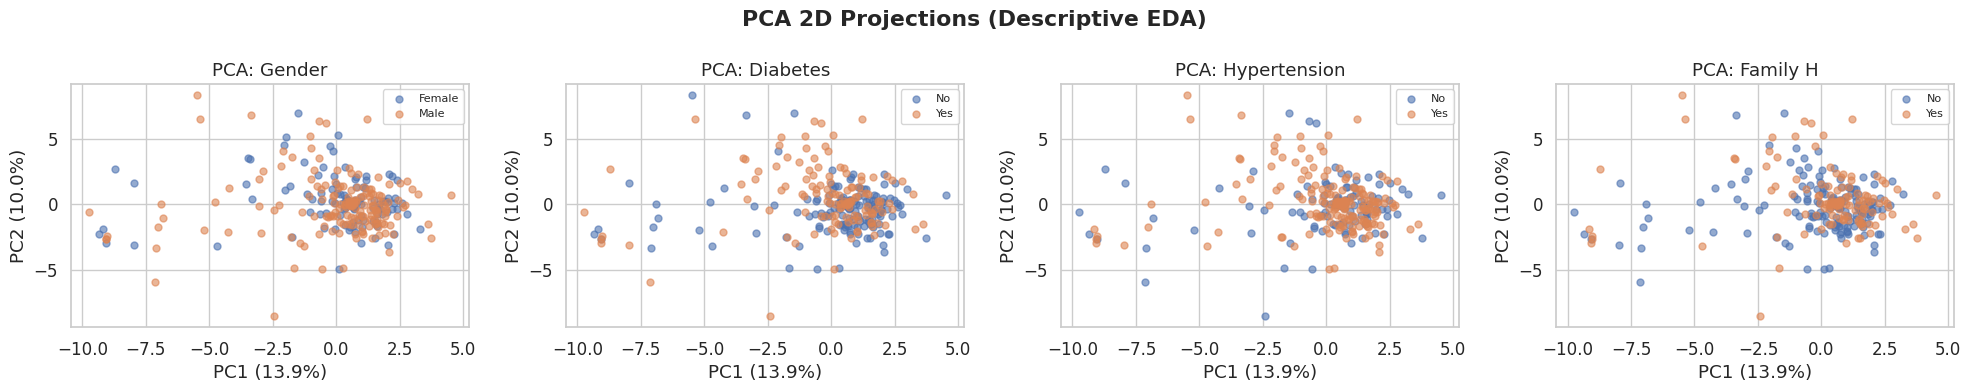

In [ ]:
# ── PCA (full dataset, descriptive only — not used for clustering) ───────────
X_pca_desc = RobustScaler().fit_transform(df_clean[NUM_COLS])

pca_full = PCA().fit(X_pca_desc)
explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)
n80 = np.argmax(cumulative>=0.80)+1

fig, axes = plt.subplots(1,2,figsize=(14,5))
axes[0].bar(range(1,len(explained)+1), explained*100, color='steelblue', alpha=0.8)
axes[0].set_title('Scree Plot'); axes[0].set_xlabel('PC'); axes[0].set_ylabel('Variance (%)')
axes[1].plot(range(1,len(cumulative)+1), cumulative*100,'o-',color='darkblue',linewidth=2)
axes[1].axhline(80, color='orange', linestyle='--', label=f'80% → PC{n80}')
axes[1].set_title('Cumulative Variance'); axes[1].legend()
axes[1].set_xlabel('Number of PCs'); axes[1].set_ylabel('Cumulative Variance (%)')
plt.suptitle('PCA Variance Explained (Descriptive EDA)', fontweight='bold'); plt.tight_layout(); plt.show()
print(f'PCs needed for 80% variance: {n80}')

pca2_desc = PCA(n_components=2)
pca_coords_desc = pca2_desc.fit_transform(X_pca_desc)

fig, axes = plt.subplots(1,len(cat_valid),figsize=(5*len(cat_valid),4))
if len(cat_valid)==1: axes=[axes]
for ax,col in zip(axes,cat_valid):
    grp_data = pd.DataFrame(pca_coords_desc,columns=['PC1','PC2'])
    grp_data['label'] = df_clean[col].map(LABEL_MAP.get(col,{})).values
    for lbl, grp in grp_data.dropna(subset=['label']).groupby('label'):
        ax.scatter(grp['PC1'],grp['PC2'],label=lbl,alpha=0.6,s=25)
    ax.set_title(f'PCA: {col}'); ax.legend(fontsize=8)
    ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}%)')
plt.suptitle('PCA 2D Projections (Descriptive EDA)', fontweight='bold'); plt.tight_layout(); plt.show()


### Section 11 — Outlier & Anomaly Detection

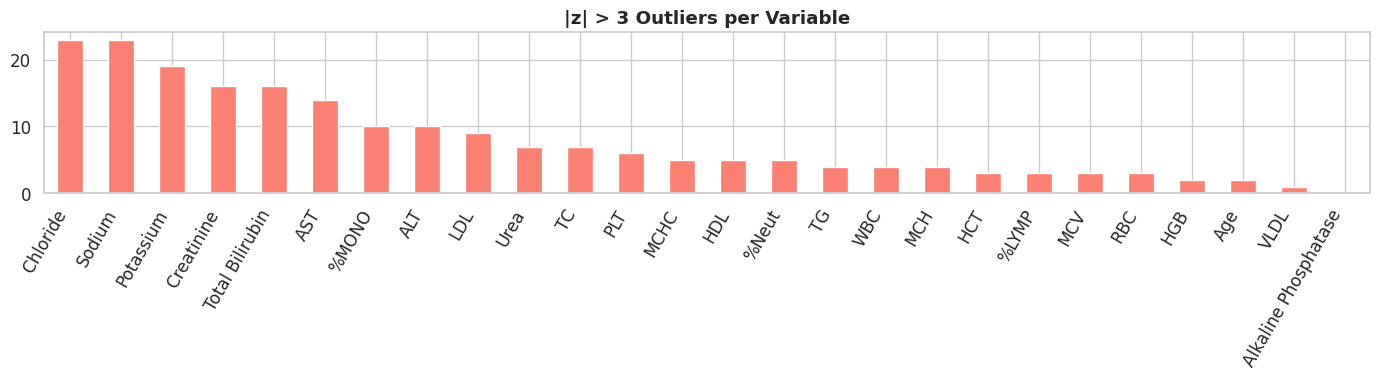

Patients with ≥1 outlier value: 102


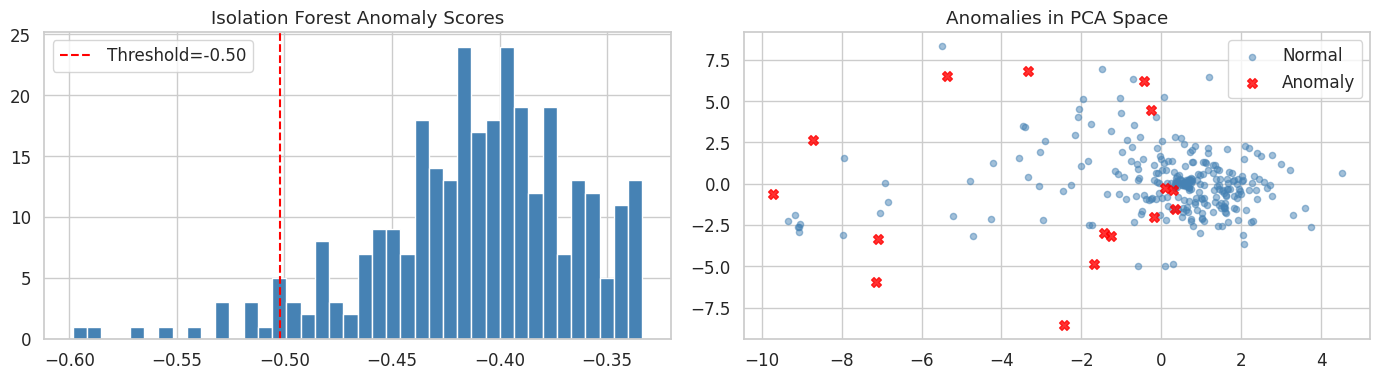

Anomalies detected: 16


In [ ]:
# ── Z-score outliers ─────────────────────────────────────────────────────────
z_df = df_clean[NUM_COLS].apply(zscore, nan_policy='omit')
outlier_counts = (z_df.abs()>3).sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(14,4))
outlier_counts.plot(kind='bar',color='salmon',edgecolor='white',ax=ax)
ax.set_title('|z| > 3 Outliers per Variable', fontweight='bold')
plt.xticks(rotation=60,ha='right'); plt.tight_layout(); plt.show()
print(f'Patients with ≥1 outlier value: {(z_df.abs()>3).any(axis=1).sum()}')

iso = IsolationForest(contamination=0.05, random_state=42)
anomaly_labels = iso.fit_predict(X_pca_desc)
anomaly_scores = iso.score_samples(X_pca_desc)
threshold = np.percentile(anomaly_scores, 5)
df_clean['anomaly'] = anomaly_labels

fig, axes = plt.subplots(1,2,figsize=(14,4))
axes[0].hist(anomaly_scores,bins=40,color='steelblue',edgecolor='white')
axes[0].axvline(threshold,color='red',linestyle='--',label=f'Threshold={threshold:.2f}')
axes[0].set_title('Isolation Forest Anomaly Scores'); axes[0].legend()
axes[1].scatter(pca_coords_desc[anomaly_labels==1,0],pca_coords_desc[anomaly_labels==1,1],
                c='steelblue',alpha=0.5,s=20,label='Normal')
axes[1].scatter(pca_coords_desc[anomaly_labels==-1,0],pca_coords_desc[anomaly_labels==-1,1],
                c='red',alpha=0.8,s=50,marker='X',label='Anomaly')
axes[1].set_title('Anomalies in PCA Space'); axes[1].legend()
plt.tight_layout(); plt.show()
print(f'Anomalies detected: {(anomaly_labels==-1).sum()}')

---
## Phase 3 — Min-Max Normalisation

### Section 12 — Normalisation (0–1 Scaling)

**Logic:** All numeric biomarkers are scaled to [0,1] so that variables with naturally larger numeric ranges (e.g. Sodium ~135-145) don't dominate distance-based algorithms (clustering, KNN) over variables with naturally smaller ranges (e.g. Total Bilirubin ~0.2-1.2). Formula: x_norm = (x − x_min) / (x_max − x_min).

In [ ]:
# ── Section 12: Min-Max Normalisation ───────────────────────────────────────
scaler_mm = MinMaxScaler()
scaler_mm.fit(df_clean.iloc[train_idx][NUM_COLS])
X_norm_full = scaler_mm.transform(df_clean[NUM_COLS])
df_norm = pd.DataFrame(X_norm_full, columns=NUM_COLS, index=df_clean.index)

for col in CAT_COLS:
    if col in df_clean.columns:
        df_norm[col] = df_clean[col].values

print(f'Normalised matrix shape: {df_norm.shape}')
print(f'Value range check (should all be 0–1):')
print(df_norm[NUM_COLS].agg(['min','max']).T.describe())
print('\n✅  Normalisation complete.')

Normalised matrix shape: (306, 30)
Value range check (should all be 0–1):
         min    max
count 26.000 26.000
mean  -0.006  1.015
std    0.017  0.053
min   -0.070  1.000
25%    0.000  1.000
50%    0.000  1.000
75%    0.000  1.000
max    0.000  1.215

✅  Normalisation complete.


---
## Phase 4 — 70:30 Train/Test Split



In [ ]:
# ── Section 13: re-display split (split itself created in Section 3) ──────
X_train = df_norm.loc[train_idx, NUM_COLS].values
X_test  = df_norm.loc[test_idx,  NUM_COLS].values

print(f'Train set: {X_train.shape[0]} patients ({TRAIN_FRAC*100:.0f}%)')
print(f'Test  set: {X_test.shape[0]} patients ({(1-TRAIN_FRAC)*100:.0f}%)')
print(f'\nClustering models (Phase 5) will be FIT on X_train only.')
print(f'X_test is held out and only used in Phase 6 for validation.')


Train set: 214 patients (70%)
Test  set: 92 patients (30%)

Clustering models (Phase 5) will be FIT on X_train only.
X_test is held out and only used in Phase 6 for validation.


---
## Phase 5 — Clustering on Train Set

### Section 14 — Five Unsupervised Models, Best Selected by Silhouette

**Logic:** Five clustering paradigms are compared, each making different structural assumptions about the data:
- **K-Means** — assumes round, equally-sized clusters
- **Fuzzy C-Means (FCM)** — allows soft/partial cluster membership, more realistic for overlapping clinical phenotypes
- **Gaussian Mixture Model (GMM)** — assumes elliptical clusters, often better for biomedical distributions
- **Hierarchical (Ward)** — builds clusters bottom-up via distance, no shape assumption
- **DBSCAN** — density-based, finds clusters of any shape and explicitly flags outlier patients as 'noise' rather than forcing them into a cluster

k=3 and k=4 are tested for each (except DBSCAN, which determines its own number of clusters from data density). The combination with the **highest silhouette score on the train set** is selected as the final clustering solution.

In [ ]:
# ── Section 14: Clustering models — FIT ON TRAIN ONLY ──────────────────────
# UMAP pre-processing reduces noise from 26 raw dimensions before clustering
print('Running UMAP on train set...')
reducer = umap_module.UMAP(n_components=5, n_neighbors=15, min_dist=0.1,
                            random_state=42)
X_train_umap = reducer.fit_transform(X_train)
X_test_umap  = reducer.transform(X_test)   # same UMAP mapping applied to test

K_TEST = [3, 4]
all_results = {}
# ── 1. K-Means ────────────────────────────────────────────────────────────
for k in K_TEST:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_train_umap)
    # Was silhouette_score(X_train, labels) — scored in the
    # original 26-dim space while every other method below is scored in
    # the 5-dim UMAP space it was actually clustered in. Mixing spaces
    # makes silhouette scores incomparable across methods and unfairly
    # biases the "best method" selection against K-Means.
    sil = silhouette_score(X_train_umap, labels)
    all_results[f'KMeans_k{k}'] = {'labels':labels,'silhouette':sil,'k':k,'model':km}
    print(f'K-Means      k={k}: Train Silhouette={sil:.4f}')

# ── 2. Fuzzy C-Means ──────────────────────────────────────────────────────
for k in K_TEST:
    cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
        X_train_umap.T, c=k, m=2.0, error=0.005, maxiter=1000, seed=42)
    labels = np.argmax(u, axis=0)
    sil = silhouette_score(X_train_umap, labels)
    all_results[f'FCM_k{k}'] = {'labels':labels,'silhouette':sil,'k':k,'centers':cntr}
    print(f'FCM          k={k}: Train Silhouette={sil:.4f}')

# ── 3. GMM ────────────────────────────────────────────────────────────────
for k in K_TEST:
    gmm = GaussianMixture(n_components=k, covariance_type='full',
                           random_state=42, n_init=5)
    labels = gmm.fit_predict(X_train_umap)
    sil = silhouette_score(X_train_umap, labels)
    all_results[f'GMM_k{k}'] = {'labels':labels,'silhouette':sil,'k':k,'model':gmm}
    print(f'GMM          k={k}: Train Silhouette={sil:.4f}  BIC={gmm.bic(X_train_umap):.1f}')

# ── 4. Hierarchical (Ward) ────────────────────────────────────────────────
for k in K_TEST:
    hc = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = hc.fit_predict(X_train_umap)
    sil = silhouette_score(X_train_umap, labels)
    all_results[f'Hierarchical_k{k}'] = {'labels':labels,'silhouette':sil,'k':k}
    print(f'Hierarchical k={k}: Train Silhouette={sil:.4f}')

# ── 5. DBSCAN (auto eps via k-distance elbow) ───────────────────────────────
# ── 5. DBSCAN — auto-tune eps and min_samples ────────────────────────────────
print('Tuning DBSCAN parameters...')
best_db = None
best_db_sil = -1

for eps in np.arange(0.1, 2.01, 0.1):
    for min_s in [3, 5, 8]:
        db_test = DBSCAN(eps=round(eps,2), min_samples=min_s)
        lbl_test = db_test.fit_predict(X_train_umap)
        n_clust = len(set(lbl_test)) - (1 if -1 in lbl_test else 0)
        n_noise = (lbl_test == -1).sum()
        noise_pct = n_noise / len(lbl_test)

        if n_clust in [3, 4] and noise_pct < 0.30:
            mask = lbl_test != -1
            sil = silhouette_score(X_train_umap[mask], lbl_test[mask])
            if sil > best_db_sil:
                best_db_sil = sil
                best_db = {'eps': round(eps,2), 'min_samples': min_s,
                           'labels': lbl_test, 'k': n_clust,
                           'noise': n_noise, 'silhouette': sil}

if best_db is not None:
    print(f"Best DBSCAN: eps={best_db['eps']}, min_samples={best_db['min_samples']}, "
          f"k={best_db['k']}, noise={best_db['noise']} "
          f"({best_db['noise']/len(X_train_umap)*100:.1f}%), "
          f"Silhouette={best_db['silhouette']:.4f}")
    all_results['DBSCAN'] = {
        'labels': best_db['labels'], 'silhouette': best_db['silhouette'],
        'k': best_db['k'], 'noise': best_db['noise'], 'eps': best_db['eps']
    }
else:
    print('No DBSCAN configuration found 3-4 clusters with <30% noise — excluded')

Running UMAP on train set...
K-Means      k=3: Train Silhouette=0.3611
K-Means      k=4: Train Silhouette=0.3069
FCM          k=3: Train Silhouette=0.2635
FCM          k=4: Train Silhouette=0.2682
GMM          k=3: Train Silhouette=0.3468  BIC=1666.7
GMM          k=4: Train Silhouette=0.2961  BIC=1603.2
Hierarchical k=3: Train Silhouette=0.2496
Hierarchical k=4: Train Silhouette=0.2551
Tuning DBSCAN parameters...
Best DBSCAN: eps=0.6, min_samples=5, k=3, noise=17 (7.9%), Silhouette=0.3927


═══════════════════════════════════════════════════════
ALL CLUSTERING METHODS — RANKED BY TRAIN SILHOUETTE
═══════════════════════════════════════════════════════
         Method  k  Silhouette  Noise_pts
         DBSCAN  3       0.393         17
      KMeans_k3  3       0.361          0
         GMM_k3  3       0.347          0
      KMeans_k4  4       0.307          0
         GMM_k4  4       0.296          0
         FCM_k4  4       0.268          0
         FCM_k3  3       0.264          0
Hierarchical_k4  4       0.255          0
Hierarchical_k3  3       0.250          0


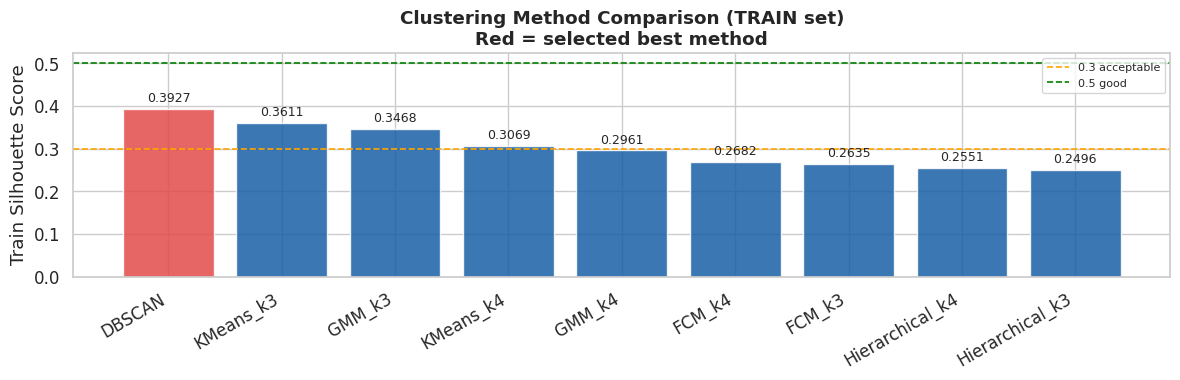


✅  Best method: DBSCAN (Train Silhouette=0.3927, k=3)

Train cluster sizes:
0    128
1     21
2     65
Name: count, dtype: int64


In [ ]:
# ── Compare all methods, select best by TRAIN silhouette ───────────────────
compare_df = pd.DataFrame([
    {'Method':key,'k':val['k'],'Silhouette':round(val['silhouette'],4),
     'Noise_pts':val.get('noise',0)}
    for key,val in all_results.items()
]).sort_values('Silhouette', ascending=False).reset_index(drop=True)

print('═'*55)
print('ALL CLUSTERING METHODS — RANKED BY TRAIN SILHOUETTE')
print('═'*55)
print(compare_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(12,4))
colors_bar = ['#E24B4A' if i==0 else '#185FA5' for i in range(len(compare_df))]
bars = ax.bar(compare_df['Method'], compare_df['Silhouette'],
              color=colors_bar, alpha=0.85, edgecolor='white')
ax.bar_label(bars, labels=[f'{v:.4f}' for v in compare_df['Silhouette']],
             padding=3, fontsize=9)
ax.set_ylabel('Train Silhouette Score')
ax.set_title('Clustering Method Comparison (TRAIN set)\nRed = selected best method',
             fontweight='bold')
ax.axhline(0.3,color='orange',linestyle='--',linewidth=1.2,label='0.3 acceptable')
ax.axhline(0.5,color='green',linestyle='--',linewidth=1.2,label='0.5 good')
ax.legend(fontsize=8)
plt.xticks(rotation=30,ha='right'); plt.tight_layout()
plt.savefig('clustering_comparison.png',dpi=180,bbox_inches='tight'); plt.show()

best_key    = compare_df.iloc[0]['Method']
best_result = all_results[best_key]
best_k      = best_result['k']
best_method = best_key
best_sil_train = best_result['silhouette']

TRAIN_CLUSTER_LABELS = best_result['labels']
if 'DBSCAN' in best_key and -1 in TRAIN_CLUSTER_LABELS:
    noise_mask = TRAIN_CLUSTER_LABELS == -1
    clean_mask = TRAIN_CLUSTER_LABELS != -1
    knn_fill = KNeighborsClassifier(n_neighbors=3)
    # Was fit/predict on X_train (original 26-dim space) while
    # DBSCAN itself was fit on X_train_umap — inconsistent neighbour space.
    # Section 15 already did this correctly; this just matches it so the
    # interim "best method" print in this section isn't misleading.
    knn_fill.fit(X_train_umap[clean_mask], TRAIN_CLUSTER_LABELS[clean_mask])
    filled = TRAIN_CLUSTER_LABELS.copy()
    filled[noise_mask] = knn_fill.predict(X_train_umap[noise_mask])
    TRAIN_CLUSTER_LABELS = filled

pal = sns.color_palette('tab10', best_k)
print(f'\n✅  Best method: {best_method} '
      f'(Train Silhouette={best_sil_train:.4f}, k={best_k})')
print(f'\nTrain cluster sizes:')
print(pd.Series(TRAIN_CLUSTER_LABELS).value_counts().sort_index())

---
## Phase 6 — Validate Clusters on Held-Out Test Set

### Section 15 — Assign Test Patients to Nearest Cluster

**Logic:** The 30% test set was never seen during clustering. Each test patient is now assigned to whichever train-set cluster centroid it is **closest to** (Euclidean distance in normalised feature space). If the test-set silhouette score is close to the train-set silhouette, the cluster structure **generalises** — this is a much stronger claim for a paper than silhouette computed on the same data the model was fit to. A large drop in test silhouette would indicate the clusters are overfit to the training sample.

═══════════════════════════════════════════════════════════════════════════
ALL CLUSTERING METHODS — TRAIN vs TEST SILHOUETTE
═══════════════════════════════════════════════════════════════════════════
         Method  k  Train Sil  Test Sil    Gap Generalises
      KMeans_k3  3      0.361     0.370 -0.009 ✅ Excellent
         DBSCAN  3      0.393     0.370  0.023 ✅ Excellent
         GMM_k3  3      0.347     0.354 -0.007 ✅ Excellent
         GMM_k4  4      0.296     0.281  0.015 ✅ Excellent
      KMeans_k4  4      0.307     0.276  0.031 ✅ Excellent
         FCM_k4  4      0.268     0.234  0.034 ✅ Excellent
Hierarchical_k4  4      0.255     0.233  0.023 ✅ Excellent
Hierarchical_k3  3      0.250     0.221  0.029 ✅ Excellent
         FCM_k3  3      0.264     0.220  0.043 ✅ Excellent


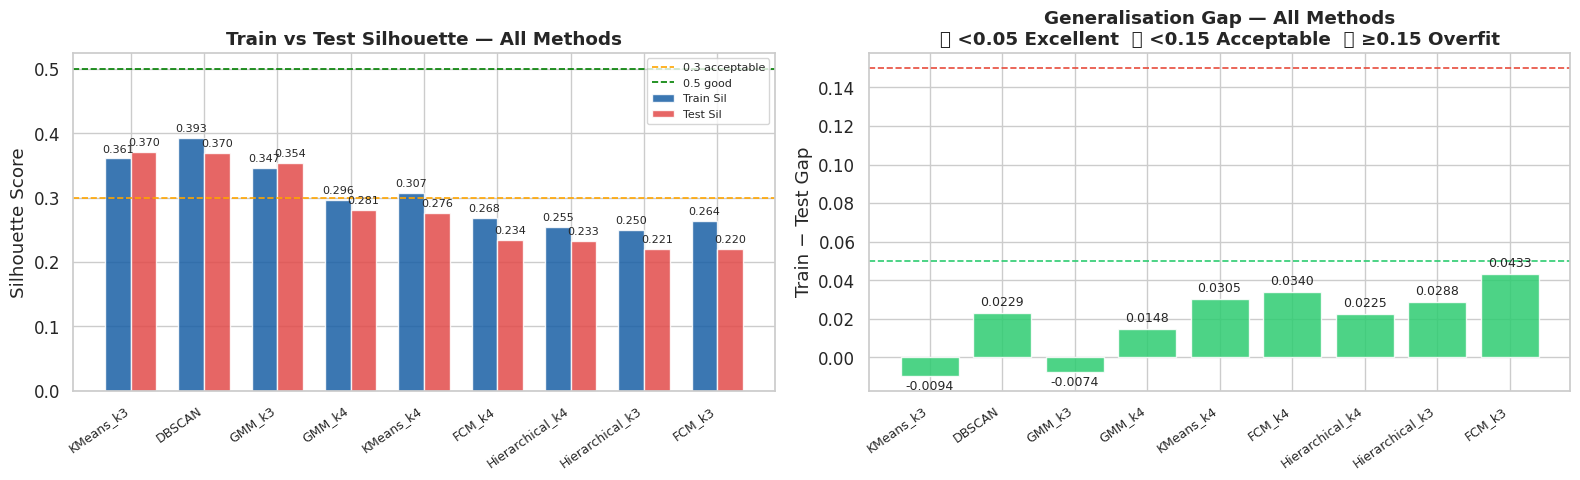


✅  Best method (by Test Sil): KMeans_k3  (Train=0.3611, Test=0.3705, Gap=-0.0094, k=3)

Final cluster distribution (306 patients):
0     39
1    186
2     81
Name: count, dtype: int64


In [ ]:
# ── Section 15: Assign test set — ALL models evaluated ─────────────────────

from scipy.spatial.distance import cdist

all_test_results = {}

for key, val in all_results.items():
    k         = val['k']
    train_lbl = val['labels'].copy()

    # ── Fill DBSCAN noise points with KNN ──────────────────────────────────
    if 'DBSCAN' in key and -1 in train_lbl:
        clean_mask = train_lbl != -1
        noise_mask = train_lbl == -1
        knn_fill   = KNeighborsClassifier(n_neighbors=3)
        knn_fill.fit(X_train_umap[clean_mask], train_lbl[clean_mask])
        train_lbl[noise_mask] = knn_fill.predict(X_train_umap[noise_mask])

    # ── Compute centroids on UMAP train space ──────────────────────────────
    centroids = np.array([
        X_train_umap[train_lbl == c].mean(axis=0) for c in range(k)
    ])

    # ── Assign test points to nearest centroid ─────────────────────────────
    dists     = cdist(X_test_umap, centroids, metric='euclidean')
    test_lbl  = np.argmin(dists, axis=1)

    # ── Test silhouette ────────────────────────────────────────────────────
    if len(np.unique(test_lbl)) >= 2:
        test_sil = silhouette_score(X_test_umap, test_lbl)
    else:
        test_sil = np.nan

    train_sil = val['silhouette']
    gap       = train_sil - (test_sil if not np.isnan(test_sil) else train_sil)

    all_test_results[key] = {
        'k'           : k,
        'train_sil'   : train_sil,
        'test_sil'    : test_sil,
        'gap'         : gap,
        'train_labels': train_lbl,
        'test_labels' : test_lbl,
    }

summary_df = pd.DataFrame([
    {
        'Method'     : key,
        'k'          : v['k'],
        'Train Sil'  : round(v['train_sil'], 4),
        'Test Sil'   : round(v['test_sil'],  4) if not np.isnan(v['test_sil']) else np.nan,
        'Gap'        : round(v['gap'],        4),
        'Generalises': ('✅ Excellent' if v['gap'] < 0.05
                        else '✅ Acceptable' if v['gap'] < 0.15
                        else '⚠️  Overfit'),
    }
    for key, v in all_test_results.items()
]).sort_values('Test Sil', ascending=False).reset_index(drop=True)

print('═' * 75)
print('ALL CLUSTERING METHODS — TRAIN vs TEST SILHOUETTE')
print('═' * 75)
print(summary_df.to_string(index=False))

# ── Bar chart: Train vs Test silhouette for all methods ────────────────────
methods   = summary_df['Method'].tolist()
train_vals = summary_df['Train Sil'].tolist()
test_vals  = summary_df['Test Sil'].tolist()

x     = np.arange(len(methods))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: grouped bar — Train vs Test
ax = axes[0]
bars1 = ax.bar(x - width/2, train_vals, width, label='Train Sil',
               color='#185FA5', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, test_vals,  width, label='Test Sil',
               color='#E24B4A', alpha=0.85, edgecolor='white')
ax.bar_label(bars1, labels=[f'{v:.3f}' for v in train_vals], padding=3, fontsize=8)
ax.bar_label(bars2, labels=[f'{v:.3f}' if not np.isnan(v) else 'NaN'
                              for v in test_vals], padding=3, fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(methods, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Silhouette Score')
ax.set_title('Train vs Test Silhouette — All Methods', fontweight='bold')
ax.axhline(0.3, color='orange', linestyle='--', linewidth=1.2, label='0.3 acceptable')
ax.axhline(0.5, color='green',  linestyle='--', linewidth=1.2, label='0.5 good')
ax.legend(fontsize=8)

# Right: Gap bar chart
ax2 = axes[1]
gap_vals   = summary_df['Gap'].tolist()
gap_colors = ['#2ecc71' if g < 0.05 else '#f39c12' if g < 0.15 else '#e74c3c'
               for g in gap_vals]
bars3 = ax2.bar(methods, gap_vals, color=gap_colors, alpha=0.85, edgecolor='white')
ax2.bar_label(bars3, labels=[f'{g:.4f}' for g in gap_vals], padding=3, fontsize=9)
ax2.set_xticks(range(len(methods)))
ax2.set_xticklabels(methods, rotation=35, ha='right', fontsize=9)
ax2.set_ylabel('Train − Test Gap')
ax2.set_title('Generalisation Gap — All Methods\n'
              '🟢 <0.05 Excellent  🟠 <0.15 Acceptable  🔴 ≥0.15 Overfit',
              fontweight='bold')
ax2.axhline(0.05, color='#2ecc71', linestyle='--', linewidth=1.2)
ax2.axhline(0.15, color='#e74c3c', linestyle='--', linewidth=1.2)

plt.tight_layout()
plt.savefig('clustering_train_test_comparison.png', dpi=180, bbox_inches='tight')
plt.show()

# ── Pick best by TEST silhouette and assign final labels ───────────────────
best_key    = summary_df.iloc[0]['Method']
best_result = all_test_results[best_key]
best_k      = best_result['k']
best_method = best_key
best_sil_train = best_result['train_sil']

TRAIN_CLUSTER_LABELS = best_result['train_labels']
TEST_CLUSTER_LABELS  = best_result['test_labels']

CLUSTER_LABELS = np.zeros(len(df_norm), dtype=int)
CLUSTER_LABELS[train_idx] = TRAIN_CLUSTER_LABELS
CLUSTER_LABELS[test_idx]  = TEST_CLUSTER_LABELS
df_clean['Cluster'] = CLUSTER_LABELS
df_clean['Split']   = 'Train'
df_clean.loc[test_idx, 'Split'] = 'Test'

X_norm = X_norm_full

print(f'\n✅  Best method (by Test Sil): {best_method}  '
      f'(Train={best_sil_train:.4f}, Test={best_result["test_sil"]:.4f}, '
      f'Gap={best_result["gap"]:.4f}, k={best_k})')
print(f'\nFinal cluster distribution ({len(df_clean)} patients):')
print(pd.Series(CLUSTER_LABELS).value_counts().sort_index())


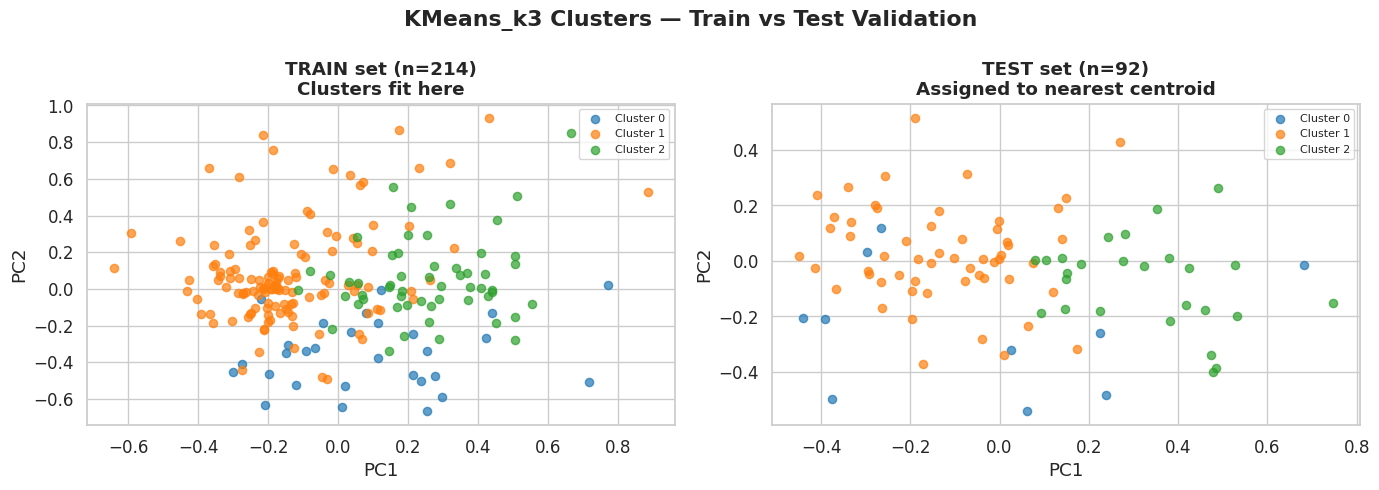

In [ ]:
# ── Visualise train vs test cluster assignment (PCA space) ─────────────────
pca2 = PCA(n_components=2)
pca_all = pca2.fit_transform(X_norm)

fig, axes = plt.subplots(1,2,figsize=(14,5))
for k in range(best_k):
    idx_tr = (CLUSTER_LABELS==k) & (df_clean['Split']=='Train').values
    idx_te = (CLUSTER_LABELS==k) & (df_clean['Split']=='Test').values
    axes[0].scatter(pca_all[idx_tr,0],pca_all[idx_tr,1],
                    color=pal[k],alpha=0.7,s=35,label=f'Cluster {k}')
    axes[1].scatter(pca_all[idx_te,0],pca_all[idx_te,1],
                    color=pal[k],alpha=0.7,s=35,label=f'Cluster {k}')
axes[0].set_title(f'TRAIN set (n={len(train_idx)})\nClusters fit here',fontweight='bold')
axes[1].set_title(f'TEST set (n={len(test_idx)})\nAssigned to nearest centroid',fontweight='bold')
for ax in axes:
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.legend(fontsize=8)
plt.suptitle(f'{best_method} Clusters — Train vs Test Validation',fontweight='bold')
plt.tight_layout()
plt.savefig('train_test_clusters.png',dpi=180,bbox_inches='tight')
plt.show()

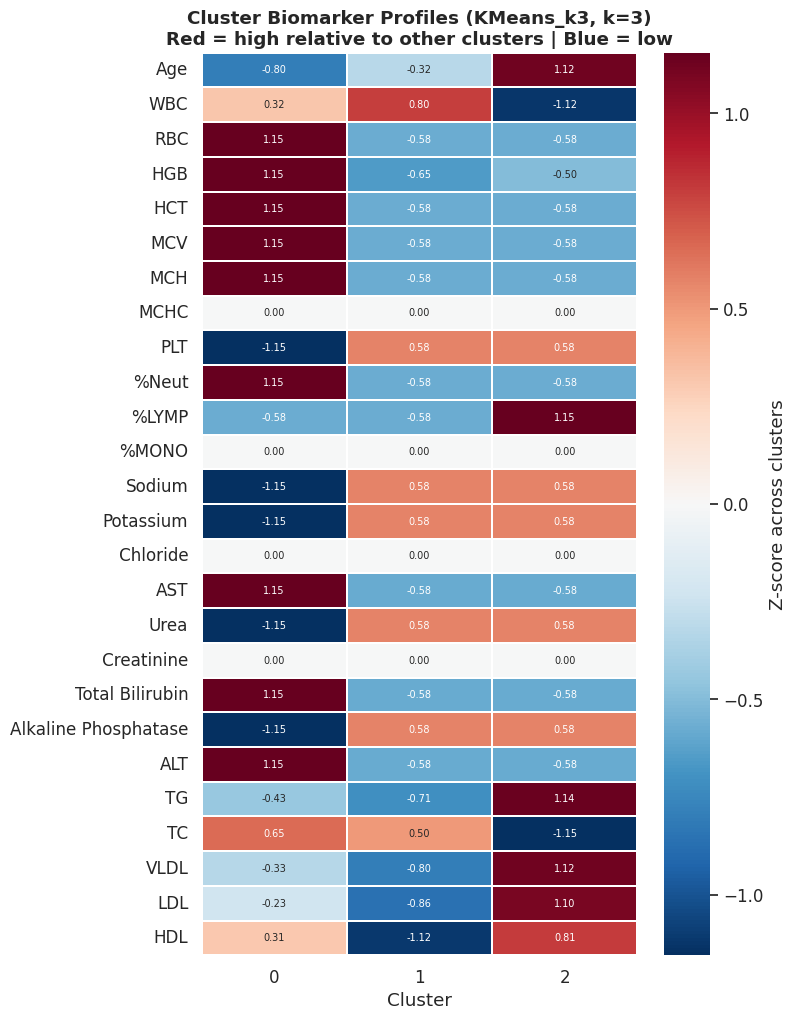


SUGGESTED PHENOTYPE NAMES

Cluster 0 (n=39):
  High: Total Bilirubin (+1.15), AST (+1.15), ALT (+1.15)
  Low : Sodium (-1.15), Potassium (-1.15), Alkaline Phosphatase (-1.15)

Cluster 1 (n=186):
  High: WBC (+0.80), Alkaline Phosphatase (+0.58), Potassium (+0.58)
  Low : VLDL (-0.80), LDL (-0.86), HDL (-1.12)

Cluster 2 (n=81):
  High: %LYMP (+1.15), TG (+1.14), VLDL (+1.12)
  Low : Total Bilirubin (-0.58), WBC (-1.12), TC (-1.15)


In [ ]:
# ── Cluster biomarker profile heatmap (z-scored medians) ───────────────────
df_norm_full = pd.DataFrame(X_norm, columns=NUM_COLS, index=df_clean.index)
df_norm_full['Cluster'] = CLUSTER_LABELS

cluster_medians = df_norm_full.groupby('Cluster')[NUM_COLS].median().T
z_prof = (cluster_medians - cluster_medians.mean(axis=1).values.reshape(-1,1)) / \
          (cluster_medians.std(axis=1).values.reshape(-1,1) + 1e-8)

fig, ax = plt.subplots(figsize=(max(8, best_k*2.5), max(10, len(NUM_COLS)*0.4)))
sns.heatmap(z_prof, cmap='RdBu_r', center=0, linewidths=0.3,
            annot=True, fmt='.2f', annot_kws={'size':7},
            ax=ax, cbar_kws={'label':'Z-score across clusters'})
ax.set_title(f'Cluster Biomarker Profiles ({best_method}, k={best_k})\n'
             'Red = high relative to other clusters | Blue = low', fontweight='bold')
plt.tight_layout()
plt.savefig('cluster_profile_heatmap.png', dpi=180, bbox_inches='tight')
plt.show()

# ── Suggested phenotype names ──────────────────────────────────────────────
print('\nSUGGESTED PHENOTYPE NAMES')
for c in range(best_k):
    profile = z_prof[c].sort_values(ascending=False)
    n = (CLUSTER_LABELS==c).sum()
    high_str = ', '.join([f'{v} ({s:+.2f})' for v,s in profile.head(3).items()])
    low_str  = ', '.join([f'{v} ({s:+.2f})' for v,s in profile.tail(3).items()])
    print(f'\nCluster {c} (n={n}):')
    print(f'  High: {high_str}')
    print(f'  Low : {low_str}')

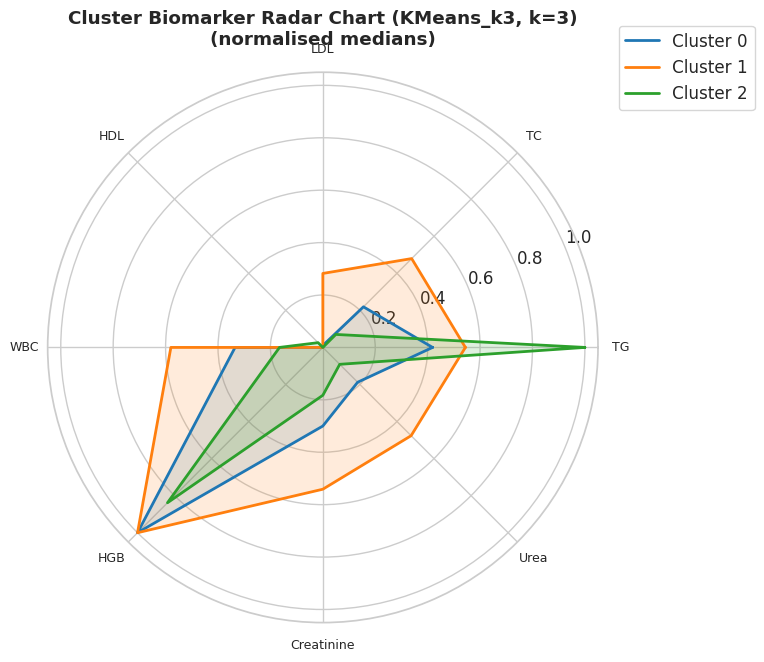

Saved: cluster_radar.png


In [ ]:
# ── Cluster biomarker radar chart ───────────────────────────────────────────
radar_cols = [c for c in ['TG','TC','LDL','HDL','WBC','HGB','Creatinine','Urea',
                          'AST','ALT','Total Bilirubin']
             if c in df_norm_full.columns][:8]   # cap at 8 axes for readability

if len(radar_cols) >= 4:
    med = df_norm_full.groupby('Cluster')[radar_cols].median()
    med_sc = pd.DataFrame(MinMaxScaler().fit_transform(med.T).T,
                          index=med.index, columns=radar_cols)

    N = len(radar_cols)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist() + [0]

    fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))
    for k,(idx,row) in enumerate(med_sc.iterrows()):
        vals = row.tolist() + row.tolist()[:1]
        ax.plot(angles, vals, linewidth=2, color=pal[k], label=f'Cluster {idx}')
        ax.fill(angles, vals, alpha=0.15, color=pal[k])

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_cols, fontsize=9)
    ax.set_title(f'Cluster Biomarker Radar Chart ({best_method}, k={best_k})\n'
                 '(normalised medians)', fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3,1.1))
    plt.tight_layout()
    plt.savefig('cluster_radar.png', dpi=180, bbox_inches='tight')
    plt.show()
    print('Saved: cluster_radar.png')
else:
    print('Not enough common biomarker columns available for radar chart')

---
## Phase 7 — Random Forest Feature Importance

### Section 16 — Feature Ranking via RFE + Random Forest

**Logic:** Random Forest is trained on the **train set** to predict cluster membership, then evaluated on the held-out **test set**. Recursive Feature Elimination (RFECV) identifies the minimal set of biomarkers that maintains accuracy — removing redundant variables one at a time and tracking cross-validated performance on train data only.

In [ ]:
# ── Section 16: RFE with Random Forest — trained on TRAIN, tested on TEST ──
y_train_cl = TRAIN_CLUSTER_LABELS
y_test_cl  = TEST_CLUSTER_LABELS

rf_rfe = RandomForestClassifier(
    n_estimators=200, min_samples_leaf=5,
    class_weight='balanced', random_state=42, n_jobs=-1
)
cv_rfe = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('Running RFECV on train set... (5–10 minutes)')
rfe = RFECV(
    estimator=rf_rfe, step=1, cv=cv_rfe,
    scoring='accuracy', min_features_to_select=5, n_jobs=-1
)
rfe.fit(X_train, y_train_cl)

optimal_n  = rfe.n_features_
selected_features   = [NUM_COLS[i] for i in range(len(NUM_COLS)) if rfe.support_[i]]
sel_idx = [NUM_COLS.index(f) for f in selected_features]

print(f'\n✅  Optimal features: {optimal_n} (from {len(NUM_COLS)})')
print(f'Selected: {selected_features}')

Running RFECV on train set... (5–10 minutes)

✅  Optimal features: 12 (from 26)
Selected: ['Age', 'HGB', 'HCT', 'AST', 'Urea', 'Total Bilirubin', 'ALT', 'TG', 'TC', 'VLDL', 'LDL', 'HDL']


Random Forest Train Accuracy: 0.939
Random Forest Test  Accuracy: 0.783


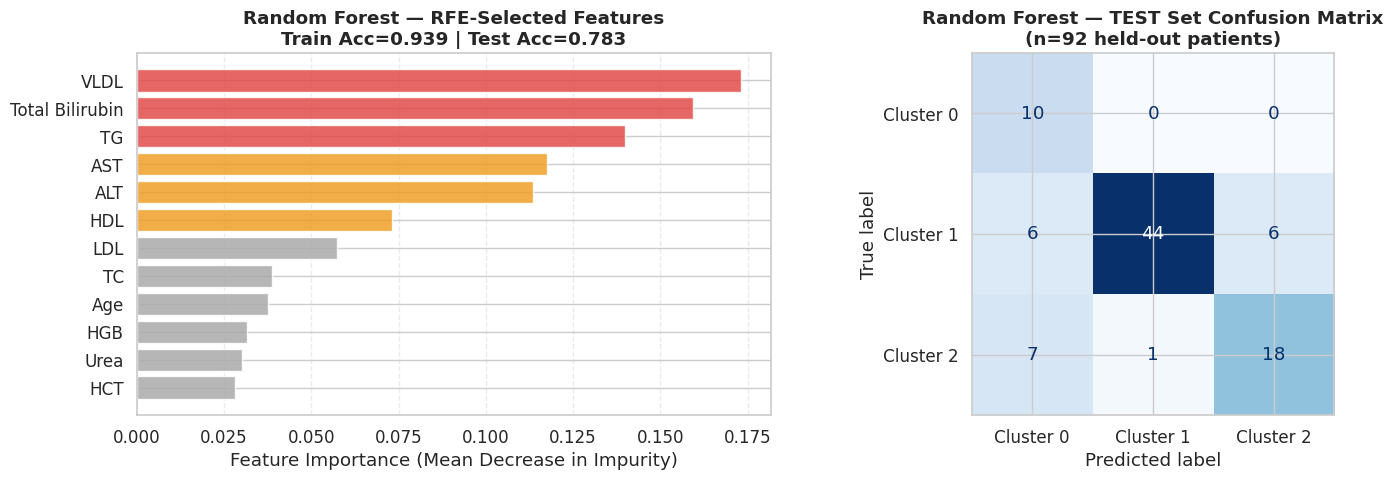


Test Set Classification Report:
              precision    recall  f1-score   support

   Cluster 0       0.43      1.00      0.61        10
   Cluster 1       0.98      0.79      0.87        56
   Cluster 2       0.75      0.69      0.72        26

    accuracy                           0.78        92
   macro avg       0.72      0.83      0.73        92
weighted avg       0.85      0.78      0.80        92



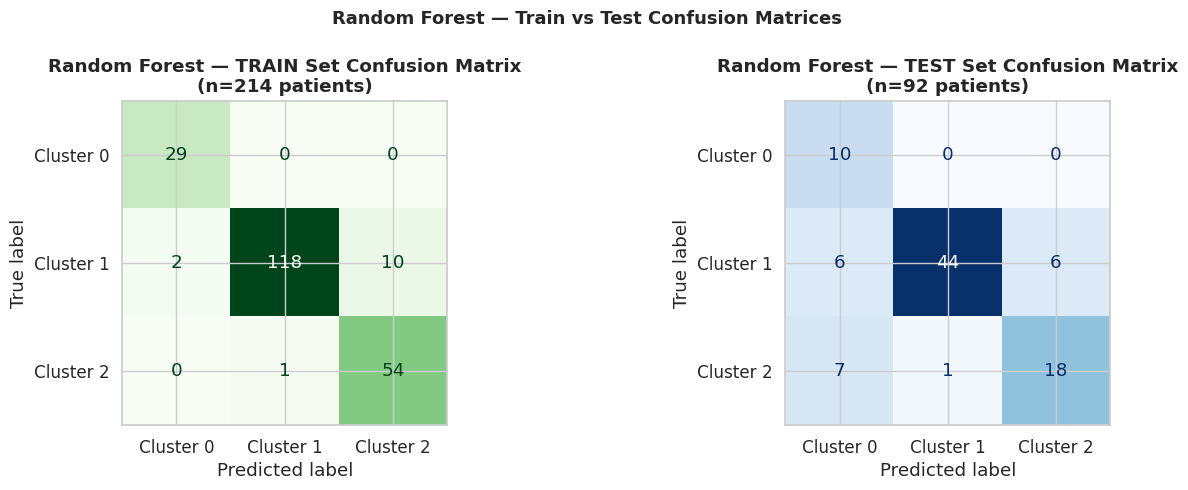

TRAIN Set Classification Report:
              precision    recall  f1-score   support

   Cluster 0       0.94      1.00      0.97        29
   Cluster 1       0.99      0.91      0.95       130
   Cluster 2       0.84      0.98      0.91        55

    accuracy                           0.94       214
   macro avg       0.92      0.96      0.94       214
weighted avg       0.95      0.94      0.94       214



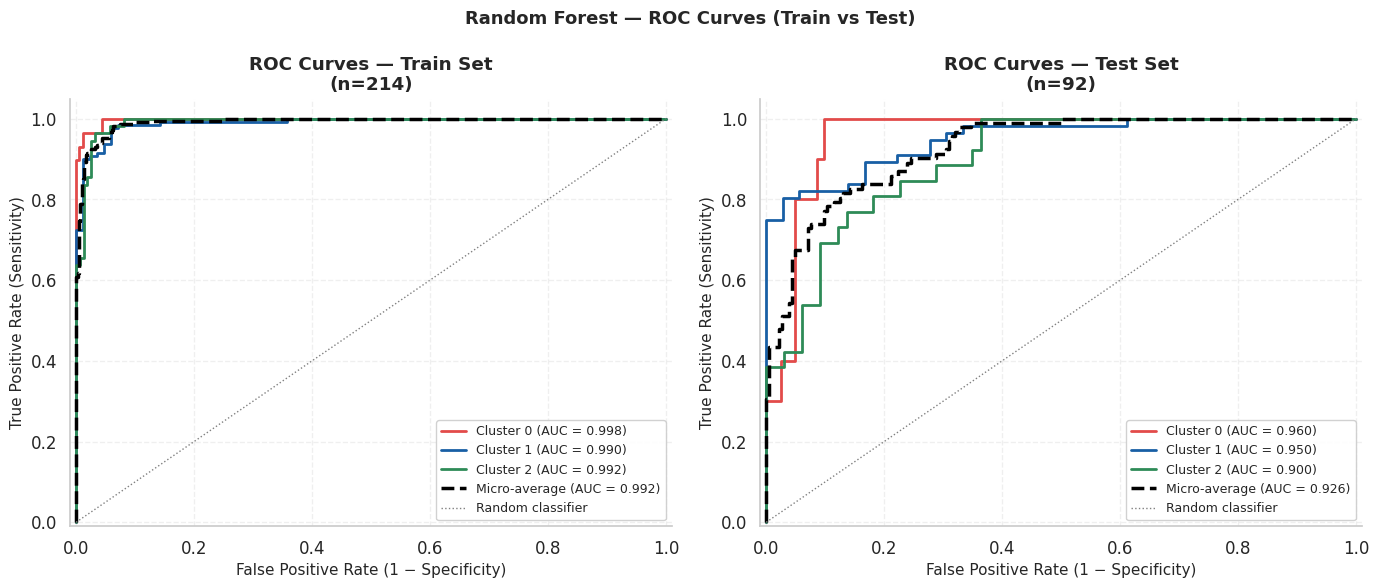

AUC Summary:
Cluster       Train AUC   Test AUC
───────────────────────────────────
Cluster 0          0.998      0.960
Cluster 1          0.990      0.950
Cluster 2          0.992      0.900
───────────────────────────────────
Micro-avg         0.926  (test only)

Saved: rf_confusion_matrices.png, rf_roc_curves.png


In [ ]:
# ── Final Random Forest — feature importance + train/test evaluation ───────
X_train_sel = X_train[:, sel_idx]
X_test_sel  = X_test[:,  sel_idx]

rf_final = RandomForestClassifier(
    n_estimators=500, min_samples_leaf=5,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_final.fit(X_train_sel, y_train_cl)

train_acc = rf_final.score(X_train_sel, y_train_cl)
test_acc  = rf_final.score(X_test_sel,  y_test_cl)
print(f'Random Forest Train Accuracy: {train_acc:.3f}')
print(f'Random Forest Test  Accuracy: {test_acc:.3f}')

final_imp = pd.DataFrame({
    'Feature':selected_features,
    'Importance':rf_final.feature_importances_
}).sort_values('Importance', ascending=True)

fig, axes = plt.subplots(1,2,figsize=(15,5))
q75=final_imp['Importance'].quantile(0.75); q50=final_imp['Importance'].quantile(0.50)
bar_colors=['#E24B4A' if v>=q75 else '#EF9F27' if v>=q50 else '#AAAAAA'
            for v in final_imp['Importance']]
axes[0].barh(final_imp['Feature'],final_imp['Importance'],
             color=bar_colors,alpha=0.85,edgecolor='white')
axes[0].set_xlabel('Feature Importance (Mean Decrease in Impurity)')
axes[0].set_title(f'Random Forest — RFE-Selected Features\n'
                  f'Train Acc={train_acc:.3f} | Test Acc={test_acc:.3f}',fontweight='bold')
axes[0].grid(axis='x',linestyle='--',alpha=0.4)

y_test_pred = rf_final.predict(X_test_sel)
cm = confusion_matrix(y_test_cl, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=[f'Cluster {k}' for k in range(best_k)])
disp.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title(f'Random Forest — TEST Set Confusion Matrix\n'
                  f'(n={len(y_test_cl)} held-out patients)',fontweight='bold')
plt.tight_layout()
plt.savefig('rf_importance_and_test.png',dpi=180,bbox_inches='tight')

plt.show()

print('\nTest Set Classification Report:')
print(classification_report(y_test_cl, y_test_pred,
      target_names=[f'Cluster {k}' for k in range(best_k)]))

# ── RF: Training confusion matrix + classification report ─────────────────────
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_train_pred = rf_final.predict(X_train_sel)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training confusion matrix
cm_train = confusion_matrix(y_train_cl, y_train_pred)
disp_train = ConfusionMatrixDisplay(
    confusion_matrix=cm_train,
    display_labels=[f'Cluster {k}' for k in range(best_k)]
)
disp_train.plot(ax=axes[0], cmap='Greens', colorbar=False)
axes[0].set_title(f'Random Forest — TRAIN Set Confusion Matrix\n'
                  f'(n={len(y_train_cl)} patients)',
                  fontweight='bold')

# Test confusion matrix repeated side by side for direct visual comparison
cm_test = confusion_matrix(y_test_cl, y_test_pred)
disp_test = ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=[f'Cluster {k}' for k in range(best_k)]
)
disp_test.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title(f'Random Forest — TEST Set Confusion Matrix\n'
                  f'(n={len(y_test_cl)} patients)',
                  fontweight='bold')

plt.suptitle('Random Forest — Train vs Test Confusion Matrices',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('rf_confusion_matrices.png', dpi=180, bbox_inches='tight')
plt.show()

print('TRAIN Set Classification Report:')
print(classification_report(y_train_cl, y_train_pred,
      target_names=[f'Cluster {k}' for k in range(best_k)]))

# ── RF: ROC curves — Train and Test ──────────────────────────────────────────
# Binarize labels for multiclass ROC
classes   = list(range(best_k))
y_train_bin = label_binarize(y_train_cl, classes=classes)
y_test_bin  = label_binarize(y_test_cl,  classes=classes)

y_train_prob = rf_final.predict_proba(X_train_sel)
y_test_prob  = rf_final.predict_proba(X_test_sel)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
cluster_colors = ['#E24B4A', '#185FA5', '#2E8B57', '#8B4789']

for split_idx, (split_name, y_bin, y_prob, ax) in enumerate([
    ('Train', y_train_bin, y_train_prob, axes[0]),
    ('Test',  y_test_bin,  y_test_prob,  axes[1])
]):
    auc_scores = []
    for k in classes:
        if y_bin.shape[1] > 1:
            fpr, tpr, _ = roc_curve(y_bin[:, k], y_prob[:, k])
        else:
            fpr, tpr, _ = roc_curve(y_bin.ravel(), y_prob[:, k])
        roc_auc = auc(fpr, tpr)
        auc_scores.append(roc_auc)
        ax.plot(fpr, tpr,
                color=cluster_colors[k % len(cluster_colors)],
                linewidth=2,
                label=f'Cluster {k} (AUC = {roc_auc:.3f})')

    # Micro-average ROC
    if y_bin.shape[1] > 1:
        fpr_micro, tpr_micro, _ = roc_curve(
            y_bin.ravel(), y_prob.ravel())
        auc_micro = auc(fpr_micro, tpr_micro)
        ax.plot(fpr_micro, tpr_micro,
                color='black', linewidth=2.5, linestyle='--',
                label=f'Micro-average (AUC = {auc_micro:.3f})')

    # Reference diagonal
    ax.plot([0, 1], [0, 1], color='grey', linewidth=1,
            linestyle=':', label='Random classifier')

    ax.set_xlim([-0.01, 1.01])
    ax.set_ylim([-0.01, 1.05])
    ax.set_xlabel('False Positive Rate (1 − Specificity)',
                  fontsize=11)
    ax.set_ylabel('True Positive Rate (Sensitivity)',
                  fontsize=11)
    ax.set_title(f'ROC Curves — {split_name} Set\n'
                 f'(n={len(y_train_cl) if split_name=="Train" else len(y_test_cl)})',
                 fontweight='bold')
    ax.legend(loc='lower right', fontsize=9, framealpha=0.9)
    ax.grid(linestyle='--', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Random Forest — ROC Curves (Train vs Test)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('rf_roc_curves.png', dpi=180, bbox_inches='tight')
plt.show()

# ── AUC summary table ─────────────────────────────────────────────────────────
print('AUC Summary:')
print(f'{"Cluster":<12} {"Train AUC":>10} {"Test AUC":>10}')
print('─' * 35)
for k in classes:
    if y_train_bin.shape[1] > 1:
        _, tpr_tr, _ = roc_curve(y_train_bin[:, k], y_train_prob[:, k])
        fpr_tr, _, _ = roc_curve(y_train_bin[:, k], y_train_prob[:, k])
        fpr_te, tpr_te, _ = roc_curve(y_test_bin[:, k], y_test_prob[:, k])
        auc_tr = auc(fpr_tr, tpr_tr)
        auc_te = auc(fpr_te, tpr_te)
        print(f'Cluster {k:<5} {auc_tr:>10.3f} {auc_te:>10.3f}')
print('─' * 35)
print(f'{"Micro-avg":<12} {auc_micro:>10.3f}  (test only)')
print('\nSaved: rf_confusion_matrices.png, rf_roc_curves.png')

---
## Phase 8 — Decision Tree (Human-Readable Rules)

### Section 17 — Decision Tree Classifier

**Logic:** While Random Forest gives the *best* predictive accuracy, it is a black box of 500 trees and cannot be read by a clinician. A single, shallow Decision Tree sacrifices a little accuracy in exchange for **complete transparency** — every split is a simple, explicit threshold (e.g. 'TG ≤ 0.42') that a doctor can follow step by step. Trained on the RFE-selected features, depth limited to 4 to keep it human-readable, evaluated on the held-out test set.

Decision Tree Train Accuracy: 0.836
Decision Tree Test  Accuracy: 0.598


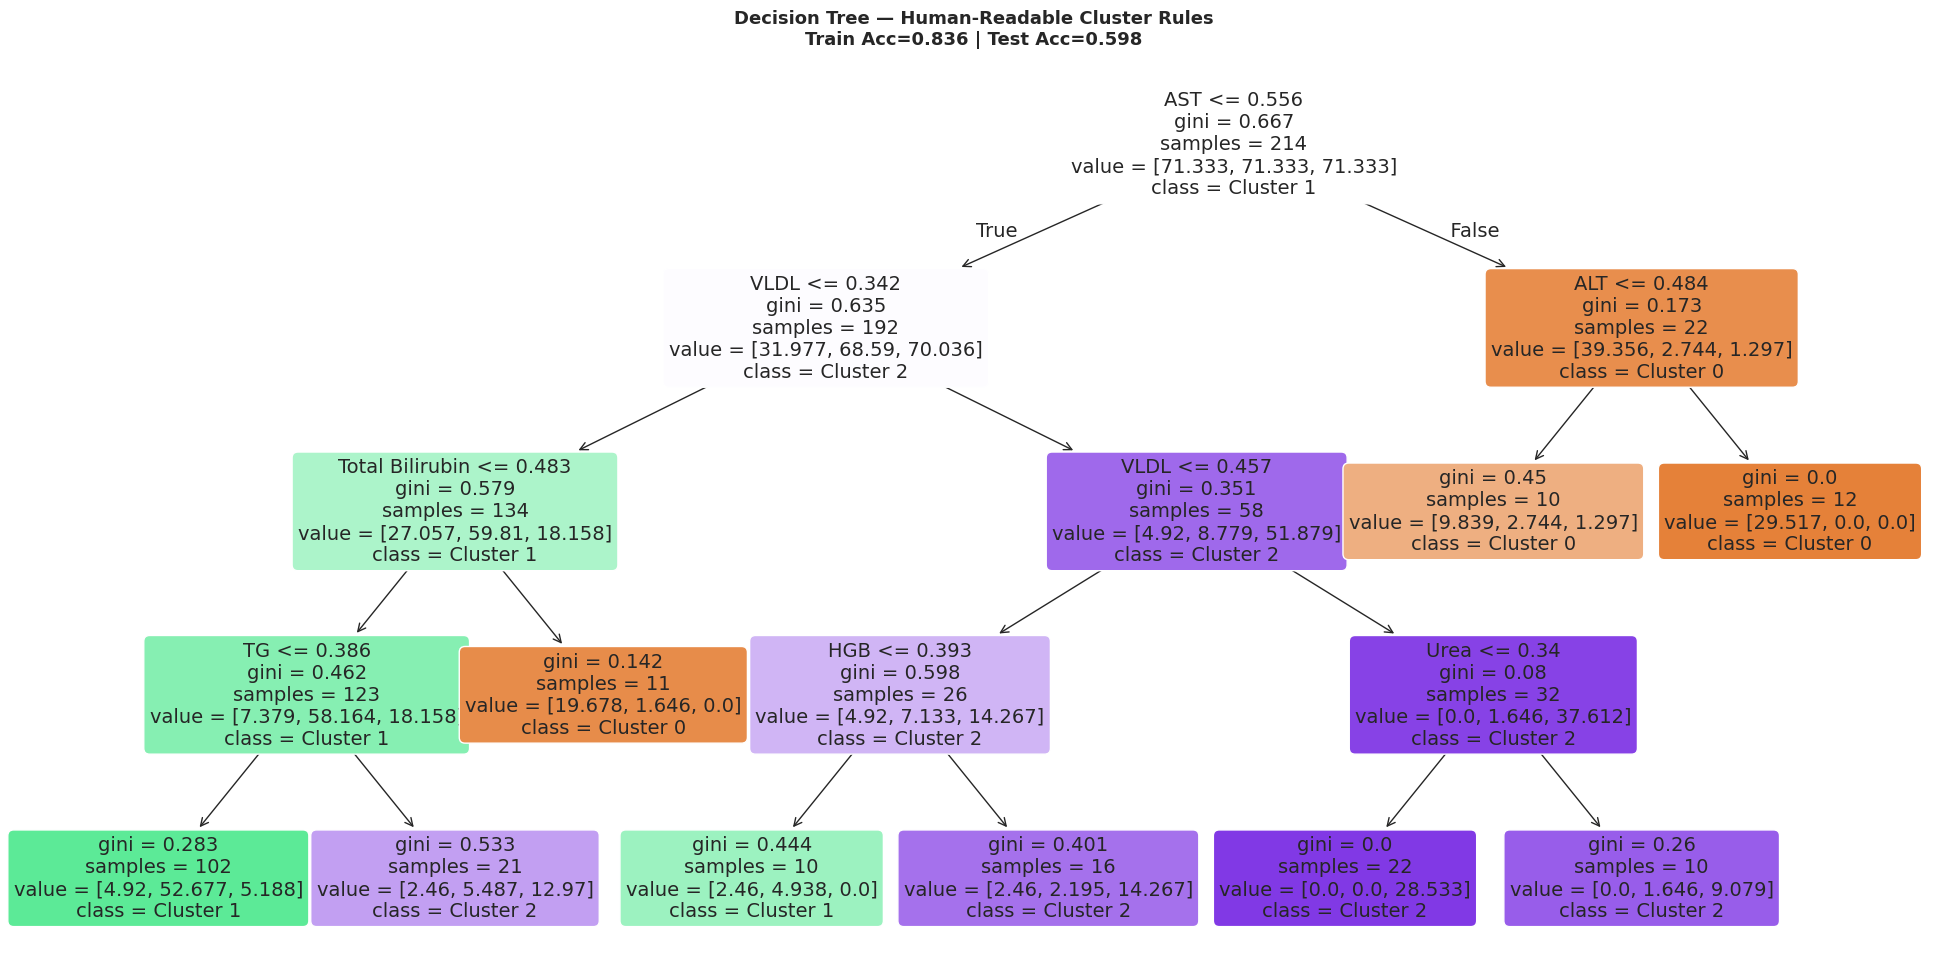


═════════════════════════════════════════════════════════════════
DECISION TREE — TEXT RULES
═════════════════════════════════════════════════════════════════
|--- AST <= 0.56
|   |--- VLDL <= 0.34
|   |   |--- Total Bilirubin <= 0.48
|   |   |   |--- TG <= 0.39
|   |   |   |   |--- class: 1
|   |   |   |--- TG >  0.39
|   |   |   |   |--- class: 2
|   |   |--- Total Bilirubin >  0.48
|   |   |   |--- class: 0
|   |--- VLDL >  0.34
|   |   |--- VLDL <= 0.46
|   |   |   |--- HGB <= 0.39
|   |   |   |   |--- class: 1
|   |   |   |--- HGB >  0.39
|   |   |   |   |--- class: 2
|   |   |--- VLDL >  0.46
|   |   |   |--- Urea <= 0.34
|   |   |   |   |--- class: 2
|   |   |   |--- Urea >  0.34
|   |   |   |   |--- class: 2
|--- AST >  0.56
|   |--- ALT <= 0.48
|   |   |--- class: 0
|   |--- ALT >  0.48
|   |   |--- class: 0



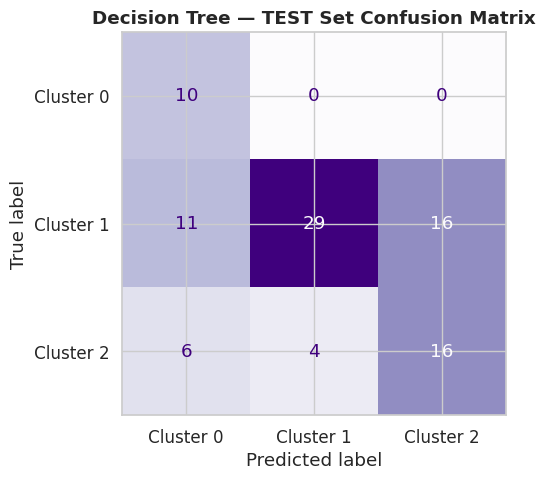

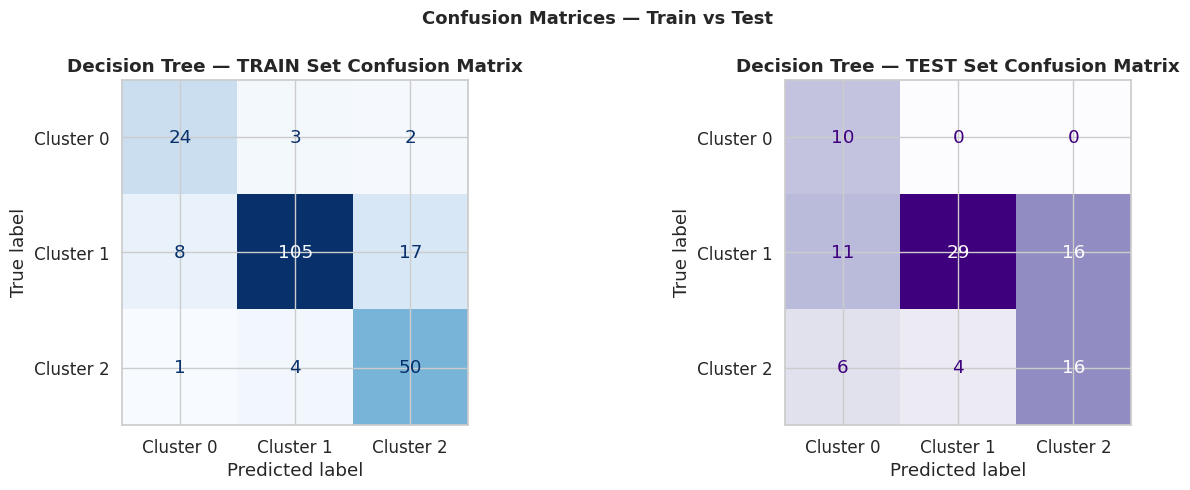

═════════════════════════════════════════════════════════════════
CLASSIFICATION REPORT — TRAIN SET
═════════════════════════════════════════════════════════════════
              precision    recall  f1-score   support

   Cluster 0       0.73      0.83      0.77        29
   Cluster 1       0.94      0.81      0.87       130
   Cluster 2       0.72      0.91      0.81        55

    accuracy                           0.84       214
   macro avg       0.80      0.85      0.82       214
weighted avg       0.85      0.84      0.84       214

═════════════════════════════════════════════════════════════════
CLASSIFICATION REPORT — TEST SET
═════════════════════════════════════════════════════════════════
              precision    recall  f1-score   support

   Cluster 0       0.37      1.00      0.54        10
   Cluster 1       0.88      0.52      0.65        56
   Cluster 2       0.50      0.62      0.55        26

    accuracy                           0.60        92
   macro avg    

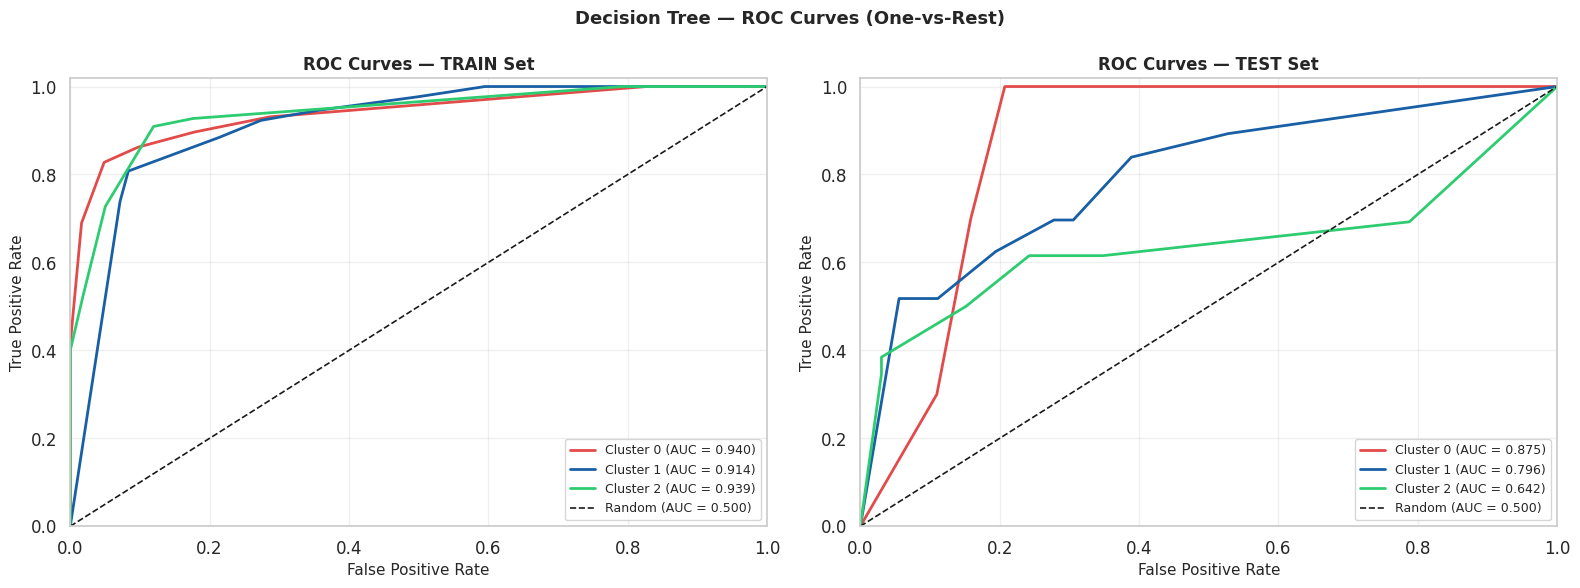

In [ ]:
# ── Section 17: Decision Tree — interpretable rules ─────────────────────────
dt = DecisionTreeClassifier(
    max_depth=4, min_samples_leaf=10,
    class_weight='balanced', random_state=42
)
dt.fit(X_train_sel, y_train_cl)

dt_train_acc = dt.score(X_train_sel, y_train_cl)
dt_test_acc  = dt.score(X_test_sel,  y_test_cl)
print(f'Decision Tree Train Accuracy: {dt_train_acc:.3f}')
print(f'Decision Tree Test  Accuracy: {dt_test_acc:.3f}')

# ── Visualise tree ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(dt, feature_names=selected_features,
          class_names=[f'Cluster {k}' for k in range(best_k)],
          filled=True, rounded=True, fontsize=14, ax=ax)
ax.set_title(f'Decision Tree — Human-Readable Cluster Rules\n'
             f'Train Acc={dt_train_acc:.3f} | Test Acc={dt_test_acc:.3f}',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('decision_tree.png', dpi=400, bbox_inches='tight')
plt.show()

# ── Text rules ────────────────────────────────────────────────────────────
tree_rules = export_text(dt, feature_names=selected_features)
print('\n' + '═'*65)
print('DECISION TREE — TEXT RULES')
print('═'*65)
print(tree_rules)

# ── Test set confusion matrix ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6,5))
y_test_pred_dt = dt.predict(X_test_sel)
cm_dt = confusion_matrix(y_test_cl, y_test_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt,
                               display_labels=[f'Cluster {k}' for k in range(best_k)])
disp.plot(ax=ax, cmap='Purples', colorbar=False)
ax.set_title(f'Decision Tree — TEST Set Confusion Matrix',fontweight='bold')
plt.tight_layout(); plt.show()

# ── Section 17 Addition: Train Confusion Matrix + Classification Report + ROC ──

from sklearn.metrics import (classification_report, roc_curve, auc)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# ── 1. Train Confusion Matrix ─────────────────────────────────────────────
y_train_pred_dt = dt.predict(X_train_sel)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_train = confusion_matrix(y_train_cl, y_train_pred_dt)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train,
                                     display_labels=[f'Cluster {k}' for k in range(best_k)])
disp_train.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Decision Tree — TRAIN Set Confusion Matrix', fontweight='bold')

cm_test = confusion_matrix(y_test_cl, y_test_pred_dt)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test,
                                    display_labels=[f'Cluster {k}' for k in range(best_k)])
disp_test.plot(ax=axes[1], cmap='Purples', colorbar=False)
axes[1].set_title('Decision Tree — TEST Set Confusion Matrix', fontweight='bold')

plt.suptitle('Confusion Matrices — Train vs Test', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('dt_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

# ── 2. Classification Reports ─────────────────────────────────────────────
print('═'*65)
print('CLASSIFICATION REPORT — TRAIN SET')
print('═'*65)
print(classification_report(y_train_cl, y_train_pred_dt,
                             target_names=[f'Cluster {k}' for k in range(best_k)]))

print('═'*65)
print('CLASSIFICATION REPORT — TEST SET')
print('═'*65)
print(classification_report(y_test_cl, y_test_pred_dt,
                             target_names=[f'Cluster {k}' for k in range(best_k)]))

# ── 3. ROC Curves — Train and Test ───────────────────────────────────────
classes    = list(range(best_k))
y_train_bin = label_binarize(y_train_cl, classes=classes)
y_test_bin  = label_binarize(y_test_cl,  classes=classes)

y_train_prob = dt.predict_proba(X_train_sel)
y_test_prob  = dt.predict_proba(X_test_sel)

colors = ['#E24B4A', '#185FA5', '#2ecc71', '#f39c12', '#9b59b6']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for split, ax, y_bin, y_prob, title in [
    ('Train', axes[0], y_train_bin, y_train_prob, 'ROC Curves — TRAIN Set'),
    ('Test',  axes[1], y_test_bin,  y_test_prob,  'ROC Curves — TEST Set'),
]:
    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        roc_auc     = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=colors[i % len(colors)], lw=2,
                label=f'Cluster {cls} (AUC = {roc_auc:.3f})')

    ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Random (AUC = 0.500)')
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.legend(loc='lower right', fontsize=9)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.grid(alpha=0.3)

plt.suptitle('Decision Tree — ROC Curves (One-vs-Rest)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('dt_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

---
## Phase 9 — ExFuzzy: Interpretable IF-THEN Rules

### Section 18 — Fuzzy Linguistic Rules (Low/Medium/High)

**Logic:** ExFuzzy converts the top RFE-selected variables into fuzzy linguistic terms (Low/Medium/High) and searches for IF-THEN combinations that best predict cluster membership. Trained on the train set, evaluated on the held-out test set. Using only the **top 4-5 features by Random Forest importance** (rather than all RFE-selected features) keeps the search space small enough for the evolutionary algorithm to find reliable, high-accuracy rules rather than spreading its search thin across many weak variables.

In [ ]:
# ── Section 18: ExFuzzy — trained on TRAIN, tested on TEST ──────────────────
import ex_fuzzy.fuzzy_sets as fs
import ex_fuzzy.evolutionary_fit as evf

# ── Use top 5 features by Random Forest importance ─────────────────────────
top_n = 7
top_features = final_imp.sort_values('Importance', ascending=False).head(top_n)
top_feature_names = top_features['Feature'].tolist()
top_feature_idx_in_sel = [selected_features.index(f) for f in top_feature_names]

print(f'Top {top_n} features for ExFuzzy:')
for i,(feat,imp) in enumerate(zip(top_feature_names, top_features['Importance']),1):
    print(f'  {i}. {feat} (importance={imp:.4f})')

X_fuzzy_train = X_train_sel[:, top_feature_idx_in_sel].astype(float)
X_fuzzy_test  = X_test_sel[:,  top_feature_idx_in_sel].astype(float)
y_fuzzy_train = y_train_cl.astype(int)
y_fuzzy_test  = y_test_cl.astype(int)
selected_features_fuzzy = top_feature_names
class_names = [f'Cluster_{k}' for k in range(best_k)]

print(f'\nExFuzzy train input: {X_fuzzy_train.shape}')
print(f'ExFuzzy test  input: {X_fuzzy_test.shape}')

# ── Build and train (TRAIN SET ONLY) ────────────────────────────────────────
fl_clf = evf.BaseFuzzyRulesClassifier(
    nRules=20, nAnts=min(3,len(selected_features_fuzzy)),
    n_linguistic_variables=3, fuzzy_type=fs.FUZZY_SETS.t1,
    class_names=class_names, verbose=False, n_class=best_k
)
print('\nTraining ExFuzzy on TRAIN set... (3–8 minutes, do not refresh)')
fl_clf.fit(X_fuzzy_train, y_fuzzy_train, n_gen=100, pop_size=50, random_state=42)
print('✅  Training complete.')

# ── Accuracy: train AND test ────────────────────────────────────────────────
y_pred_train_fuzzy = fl_clf.predict(X_fuzzy_train)
y_pred_test_fuzzy  = fl_clf.predict(X_fuzzy_test)
fuzzy_train_acc = (y_pred_train_fuzzy == y_fuzzy_train).mean()
fuzzy_test_acc  = (y_pred_test_fuzzy  == y_fuzzy_test).mean()
print(f'\nExFuzzy Train Accuracy: {fuzzy_train_acc:.3f}')
print(f'ExFuzzy Test  Accuracy: {fuzzy_test_acc:.3f}')

Top 7 features for ExFuzzy:
  1. VLDL (importance=0.1731)
  2. Total Bilirubin (importance=0.1593)
  3. TG (importance=0.1399)
  4. AST (importance=0.1176)
  5. ALT (importance=0.1134)
  6. HDL (importance=0.0732)
  7. LDL (importance=0.0573)

ExFuzzy train input: (214, 7)
ExFuzzy test  input: (92, 7)

Training ExFuzzy on TRAIN set... (3–8 minutes, do not refresh)
✅  Training complete.

ExFuzzy Train Accuracy: 0.463
ExFuzzy Test  Accuracy: 0.435


In [ ]:
# ── Print rules — fixed decoding (no corruption of DS/ACC values) ───────────
import re, io
from contextlib import redirect_stdout

f_out = io.StringIO()
with redirect_stdout(f_out):
    fl_clf.print_rules()
rules_text = f_out.getvalue()

parsed_rules = []
current_cluster = None
for line in rules_text.split('\n'):
    line = line.strip()
    if 'Rules for consequent:' in line:
        current_cluster = line.replace('Rules for consequent:', '').strip()
    elif line.startswith('IF') and 'ACC' in line:
        # Split the line BEFORE "WITH DS" so we only decode the rule part
        if 'WITH DS' in line:
            rule_part, score_part = line.split('WITH DS', 1)
        else:
            rule_part, score_part = line, ''

        acc_match = re.search(r'ACC[,\s]+([\d.]+)', line)
        ds_match  = re.search(r'DS\s+([\d.]+)', line)

        if acc_match:
            parsed_rules.append({
                'cluster' : current_cluster,
                'rule_part_raw': rule_part.strip(),   # only decode this part
                'ACC': float(acc_match.group(1)),
                'DS': float(ds_match.group(1)) if ds_match else 0
            })

rules_df = pd.DataFrame(parsed_rules)

def decode_rule(rule_raw, feat_names):
    decoded = rule_raw
    for idx, name in enumerate(feat_names):
        # Only replace whole-word digit tokens, not inside decimals
        decoded = re.sub(rf'(?<![\d.])\b{idx}\b(?![\d.])', name, decoded)
    return decoded

rules_df['rule_decoded'] = rules_df['rule_part_raw'].apply(
    lambda r: decode_rule(r, selected_features_fuzzy))

print('\n' + '═'*65)
print('ALL RULES — CLEAN OUTPUT')
print('═'*65)
for cluster in rules_df['cluster'].unique():
    print(f'\n{cluster}:')
    sub = rules_df[rules_df['cluster']==cluster].sort_values('ACC', ascending=False)
    for _, row in sub.iterrows():
        quality = '✅ HIGH' if row['ACC']>=0.7 else '⚠️  MED' if row['ACC']>=0.5 else '❌ LOW'
        print(f'  {quality} (ACC={row["ACC"]:.3f}, DS={row["DS"]:.4f})')
        print(f'  {row["rule_decoded"]}\n')


═════════════════════════════════════════════════════════════════
ALL RULES — CLEAN OUTPUT
═════════════════════════════════════════════════════════════════

Cluster_0:
  ❌ LOW (ACC=0.326, DS=0.0000)
  IF TG IS Medium AND LDL IS High

  ❌ LOW (ACC=0.092, DS=0.0031)
  IF HDL IS Low AND LDL IS Low


Cluster_1:
  ✅ HIGH (ACC=0.847, DS=0.2347)
  IF VLDL IS Low AND HDL IS Low

  ❌ LOW (ACC=0.333, DS=0.0008)
  IF Total Bilirubin IS Low AND HDL IS Low AND LDL IS Medium


Cluster_2:
  ✅ HIGH (ACC=1.000, DS=0.0021)
  IF VLDL IS High AND LDL IS Medium

  ✅ HIGH (ACC=1.000, DS=0.0090)
  IF VLDL IS High AND AST IS Low

  ✅ HIGH (ACC=0.833, DS=0.0115)
  IF TG IS Low AND LDL IS Medium

  ✅ HIGH (ACC=0.750, DS=0.0044)
  IF TG IS High AND AST IS Medium



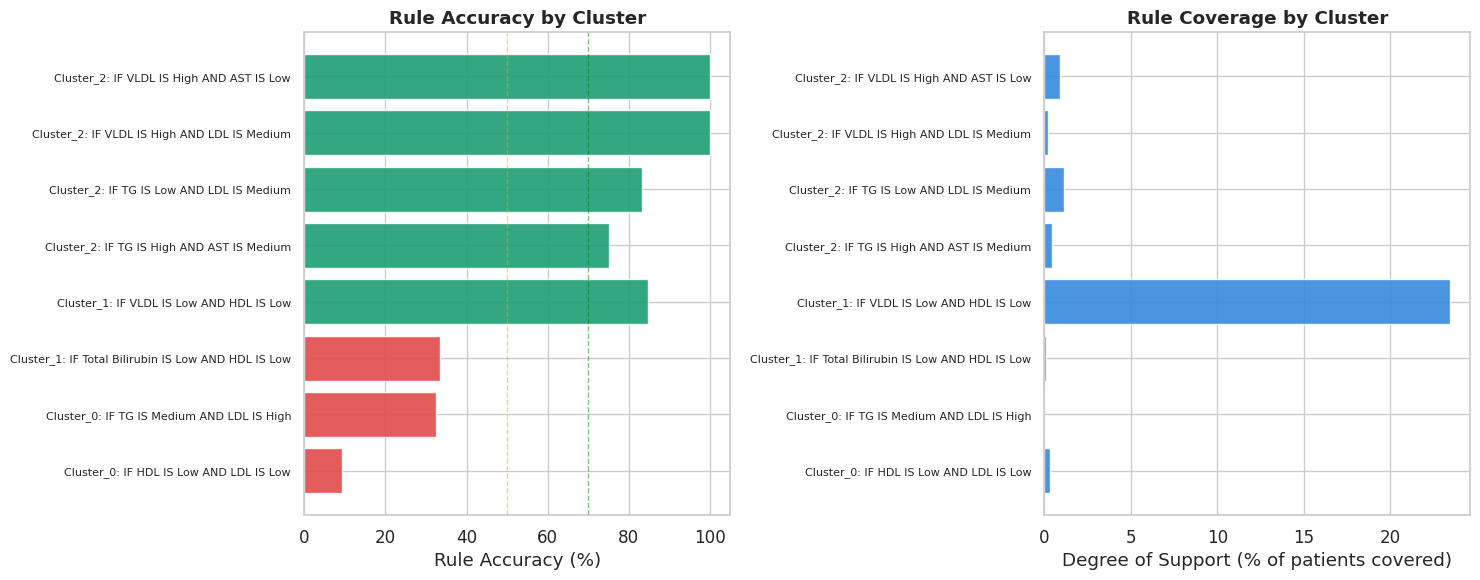

Saved: exfuzzy_rule_dashboard.png


In [ ]:
# ── Rule quality dashboard — accuracy + coverage by cluster ────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

rules_df_sorted = rules_df.sort_values(['cluster', 'ACC'], ascending=[True, True])
labels = [f"{row['cluster']}: {row['rule_decoded'][:40]}"
          for _, row in rules_df_sorted.iterrows()]
colors_acc = ['#1D9E75' if a >= 0.7 else '#EF9F27' if a >= 0.5 else '#E24B4A'
              for a in rules_df_sorted['ACC']]

# Left: accuracy
axes[0].barh(labels, rules_df_sorted['ACC']*100, color=colors_acc,
             alpha=0.9, edgecolor='white')
axes[0].axvline(70, color='green', linestyle='--', linewidth=1, alpha=0.5)
axes[0].axvline(50, color='orange', linestyle='--', linewidth=1, alpha=0.5)
axes[0].set_xlabel('Rule Accuracy (%)')
axes[0].set_xlim(0, 105)
axes[0].set_title('Rule Accuracy by Cluster', fontweight='bold')
axes[0].tick_params(axis='y', labelsize=8)

# Right: coverage (degree of support)
axes[1].barh(labels, rules_df_sorted['DS']*100, color='#378ADD',
             alpha=0.9, edgecolor='white')
axes[1].set_xlabel('Degree of Support (% of patients covered)')
axes[1].set_title('Rule Coverage by Cluster', fontweight='bold')
axes[1].tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('exfuzzy_rule_dashboard.png', dpi=180, bbox_inches='tight')
plt.show()
print('Saved: exfuzzy_rule_dashboard.png')

In [ ]:
# ── Publication-quality Sankey flow diagram ───────────────────────────────────
import plotly.graph_objects as go
import plotly.io as pio

rules_sorted = rules_df.sort_values(['cluster','ACC'], ascending=[True, False]).reset_index(drop=True)
cluster_sizes = pd.Series(CLUSTER_LABELS).value_counts().sort_index()
cluster_names = sorted(rules_df['cluster'].unique())

# ── Build Sankey node list ────────────────────────────────────────────────────
# Nodes = rules (left side) + clusters (right side)
rule_labels  = []
for _, row in rules_sorted.iterrows():
    # Clean label: remove IF/WITH DS/ACC suffix
    clean = row['rule_decoded'].replace('IF ', '').split(' WITH DS')[0].strip()
    parts = clean.split(' AND ')
    rule_labels.append('\n'.join(parts))   # one condition per line

cluster_labels_sankey = []
for c in cluster_names:
    cl_idx = int(c.split('_')[-1]) if '_' in c else 0
    n = cluster_sizes.get(cl_idx, 0)
    pct = n / len(CLUSTER_LABELS) * 100
    cluster_labels_sankey.append(f'{c}<br>n={n} ({pct:.1f}%)')

all_nodes  = rule_labels + cluster_labels_sankey
n_rules    = len(rule_labels)
n_clusters = len(cluster_labels_sankey)

# ── Colour nodes by accuracy (rules) or neutral (clusters) ───────────────────
node_colors = []
for _, row in rules_sorted.iterrows():
    if row['ACC'] >= 0.7:
        node_colors.append('rgba(29, 158, 117, 0.85)')   # green
    elif row['ACC'] >= 0.5:
        node_colors.append('rgba(239, 159, 39, 0.85)')   # amber
    else:
        node_colors.append('rgba(226, 75, 74, 0.85)')    # red

cluster_node_colors = ['rgba(55, 138, 221, 0.85)'] * n_clusters
all_node_colors = node_colors + cluster_node_colors

# ── Build links ───────────────────────────────────────────────────────────────
sources, targets, values, link_colors, link_labels = [], [], [], [], []

for i, (_, row) in enumerate(rules_sorted.iterrows()):
    cl_idx = cluster_names.index(row['cluster'])
    sources.append(i)
    targets.append(n_rules + cl_idx)

    # Scale DS to patient counts for meaningful flow width
    flow_value = max(row['DS'] * len(CLUSTER_LABELS), 1)
    values.append(round(flow_value, 1))

    if row['ACC'] >= 0.7:
        link_colors.append('rgba(29, 158, 117, 0.35)')
    elif row['ACC'] >= 0.5:
        link_colors.append('rgba(239, 159, 39, 0.35)')
    else:
        link_colors.append('rgba(226, 75, 74, 0.35)')

    link_labels.append(
        f"Accuracy: {row['ACC']:.3f}<br>"
        f"Support: {row['DS']*100:.2f}% of patients<br>"
        f"→ {row['cluster']}"
    )

# ── Build node x/y positions ──────────────────────────────────────────────────
# Rules on left (x=0.01), clusters on right (x=0.99)
node_x, node_y = [], []
rule_y_step = 0.85 / max(n_rules - 1, 1)
for i in range(n_rules):
    node_x.append(0.01)
    node_y.append(round(0.05 + i * rule_y_step, 3))

# Cluster y positions = weighted mean of their connecting rule positions
for c in cluster_names:
    rule_ys = [node_y[i] for i, (_, row) in enumerate(rules_sorted.iterrows())
               if row['cluster'] == c]
    cl_y = np.mean(rule_ys) if rule_ys else 0.5
    node_x.append(0.99)
    node_y.append(round(cl_y, 3))

# ── Build figure ──────────────────────────────────────────────────────────────
fig = go.Figure(go.Sankey(
    arrangement='snap',
    node=dict(
        pad=20,
        thickness=22,
        line=dict(color='white', width=0.5),
        label=all_nodes,
        color=all_node_colors,
        x=node_x,
        y=node_y,
        hovertemplate='%{label}<extra></extra>',
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values,
        color=link_colors,
        label=link_labels,
        hovertemplate='%{label}<extra></extra>',
    )
))

fig.update_layout(
    title=dict(
        text=(
            '<b>Fuzzy Rule-to-Cluster Flow Diagram</b><br>'
            '<sup>Flow width proportional to patient coverage (degree of support) · '
            'Colour indicates rule accuracy</sup>'
        ),
        x=0.5, xanchor='center',
        font=dict(size=16, family='Arial', color='#1a1a1a')
    ),
    font=dict(family='Arial', size=14, color='#1a1a1a'),
    paper_bgcolor='white',
    plot_bgcolor='white',
    width=1100,
    height=600,
    margin=dict(l=20, r=20, t=90, b=80),
    annotations=[
        dict(
            x=0.0, y=-0.18, xref='paper', yref='paper',
            text=(
                '<b style="color:#1D9E75">■ High accuracy (ACC ≥ 0.70)</b>   '
                '<b style="color:#EF9F27">■ Medium accuracy (0.50–0.69)</b>   '
                '<b style="color:#E24B4A">■ Low accuracy (ACC < 0.50)</b>'
            ),
            showarrow=False, font=dict(size=10, family='Arial'), align='left'
        ),
        dict(
            x=0.01, y=1.02, xref='paper', yref='paper',
            text='<b>Fuzzy Rules</b>', showarrow=False,
            font=dict(size=12, family='Arial', color='#444')
        ),
        dict(
            x=0.99, y=1.02, xref='paper', yref='paper',
            text='<b>Patient Clusters</b>', showarrow=False,
            font=dict(size=12, family='Arial', color='#444'), xanchor='right'
        ),
    ]
)

# ── Save as high-resolution PNG ───────────────────────────────────────────────
try:
    fig.write_image('rule_cluster_sankey.png', scale=3,
                    width=1100, height=600)
    print('Saved high-resolution PNG: rule_cluster_sankey.png')
except Exception:
    print('Note: install kaleido for PNG export: pip install kaleido')
    print('Displaying interactive version instead.')

fig.show()

Note: install kaleido for PNG export: pip install kaleido
Displaying interactive version instead.


In [ ]:
!pip install kaleido==0.2.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 7.8 MB/s eta 0:00:00


In [ ]:
fig.write_html('/content/rule_cluster_sankey.html')

from google.colab import files
files.download('/content/rule_cluster_sankey.html')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

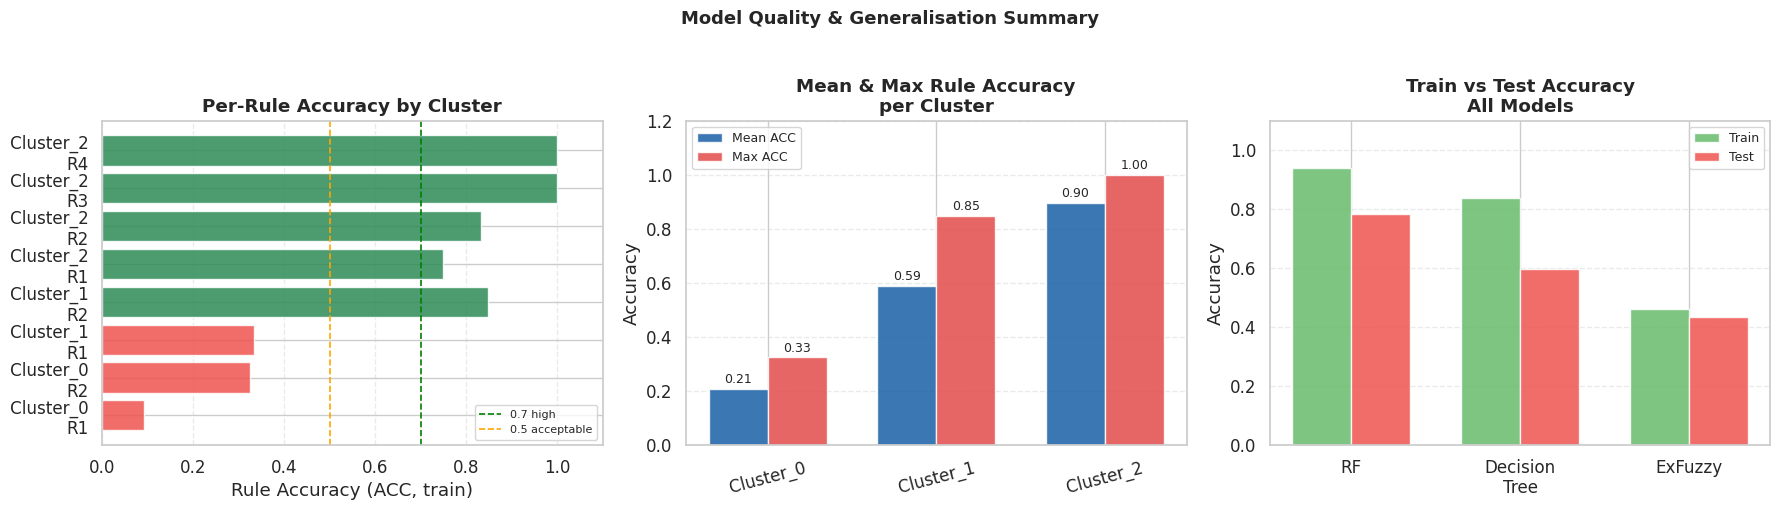

Saved: model_quality_summary.png


In [ ]:
# ── Visualisations: rule quality + train/test comparison ───────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: ACC per rule
for c_idx, cluster in enumerate(rules_df['cluster'].unique()):
    sub = rules_df[rules_df['cluster']==cluster].sort_values('ACC')
    bar_colors = ['#2E8B57' if v>=0.7 else '#FFA726' if v>=0.5 else '#EF5350'
                  for v in sub['ACC']]
    axes[0].barh([f'{cluster}\nR{i+1}' for i in range(len(sub))],
                 sub['ACC'].values, color=bar_colors, alpha=0.85, edgecolor='white')
axes[0].axvline(0.7,color='green',linestyle='--',linewidth=1.2,label='0.7 high')
axes[0].axvline(0.5,color='orange',linestyle='--',linewidth=1.2,label='0.5 acceptable')
axes[0].set_xlabel('Rule Accuracy (ACC, train)')
axes[0].set_title('Per-Rule Accuracy by Cluster',fontweight='bold')
axes[0].legend(fontsize=8); axes[0].set_xlim(0,1.1)
axes[0].grid(axis='x',linestyle='--',alpha=0.4)

# Plot 2: Mean/Max ACC per cluster
mean_acc = rules_df.groupby('cluster')['ACC'].mean()
max_acc  = rules_df.groupby('cluster')['ACC'].max()
x = np.arange(len(mean_acc)); width=0.35
b1=axes[1].bar(x-width/2,mean_acc.values,width,label='Mean ACC',color='#185FA5',alpha=0.85,edgecolor='white')
b2=axes[1].bar(x+width/2,max_acc.values,width,label='Max ACC',color='#E24B4A',alpha=0.85,edgecolor='white')
axes[1].bar_label(b1,fmt='%.2f',padding=2,fontsize=9)
axes[1].bar_label(b2,fmt='%.2f',padding=2,fontsize=9)
axes[1].set_xticks(x); axes[1].set_xticklabels(mean_acc.index,rotation=15)
axes[1].set_ylabel('Accuracy'); axes[1].set_ylim(0,1.2)
axes[1].set_title('Mean & Max Rule Accuracy\nper Cluster',fontweight='bold')
axes[1].legend(fontsize=9); axes[1].grid(axis='y',linestyle='--',alpha=0.4)

# Plot 3: Train vs Test accuracy across all models in pipeline
model_names = ['RF', 'Decision\nTree', 'ExFuzzy']
train_accs  = [train_acc, dt_train_acc, fuzzy_train_acc]
test_accs   = [test_acc,  dt_test_acc,  fuzzy_test_acc]
x2 = np.arange(len(model_names)); width=0.35
axes[2].bar(x2-width/2, train_accs, width, label='Train', color='#66BB6A', alpha=0.85, edgecolor='white')
axes[2].bar(x2+width/2, test_accs,  width, label='Test',  color='#EF5350', alpha=0.85, edgecolor='white')
axes[2].set_xticks(x2); axes[2].set_xticklabels(model_names)
axes[2].set_ylabel('Accuracy'); axes[2].set_ylim(0,1.1)
axes[2].set_title('Train vs Test Accuracy\nAll Models',fontweight='bold')
axes[2].legend(fontsize=9); axes[2].grid(axis='y',linestyle='--',alpha=0.4)

plt.suptitle('Model Quality & Generalisation Summary',fontsize=13,fontweight='bold',y=1.02)
plt.tight_layout()
plt.savefig('model_quality_summary.png',dpi=180,bbox_inches='tight')
plt.show()
print('Saved: model_quality_summary.png')